<a href="https://colab.research.google.com/github/srivishnukaushal-lab/Data-Science-Portfolio/blob/main/Kaushal_Main_Project_Predictive_Modelling_With_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Essentials**

In [ ]:
# Importing necessary libraries:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.stats.api as sms

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

import scipy.stats as stats
import pylab

In [ ]:
# Mounting the dataset from drive onto colab:

from google.colab import drive
drive.mount ("/content/drive")

dataset = pd.read_csv ("/content/drive/My Drive/Colab Notebooks/ottdata.csv")


Mounted at /content/drive


## **Data Preprocessing**

In [ ]:
# Let's get an overview of our dataset, starting with the head:
# We can see the dataset has 8 columns

dataset.head()

,visitors,ad_impressions,major_sports_event,genre,dayofweek,season,views_trailer,views_content
0,1.67,1113.81,0,Horror,Wednesday,Spring,56.70,0.51
1,1.46,1498.41,1,Thriller,Friday,Fall,52.69,0.32
2,1.47,1079.19,1,Thriller,Wednesday,Fall,48.74,0.39
3,1.85,1342.77,1,Sci-Fi,Friday,Fall,49.81,0.44
4,1.46,1498.41,0,Sci-Fi,Sunday,Winter,55.83,0.46


In [ ]:
# Now let's look at the tail:
# Based on the number of the last row, we can see the dataset has 1000 rows

dataset.tail()

,visitors,ad_impressions,major_sports_event,genre,dayofweek,season,views_trailer,views_content
995,1.58,1311.96,0,Romance,Friday,Fall,48.58,0.36
996,1.34,1329.48,0,Action,Friday,Summer,72.42,0.56
997,1.62,1359.80,1,Sci-Fi,Wednesday,Fall,150.44,0.66
998,2.06,1698.35,0,Romance,Monday,Summer,48.72,0.47
999,1.36,1140.23,0,Comedy,Saturday,Summer,52.94,0.49


In [ ]:
# Now let's confirm the number of rows and columns it has using the shape method:

a, b = dataset.shape
print ("We can confirm the dataset has ", a, "rows and ", b, "columns")

We can confirm the dataset has  1000 rows and  8 columns


In [ ]:
# Great, let's look at an information overview of the dataset to see what kind of entries these rows contain:
# We can see every column has a datatype that seems appropriate, that we can also get a sense for from our head and tail. Nothing seems off.
# We can also see of the 1000 rows all of them are non-null, meaning there are no missing values.

dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   visitors            1000 non-null   float64
 1   ad_impressions      1000 non-null   float64
 2   major_sports_event  1000 non-null   int64  
 3   genre               1000 non-null   object 
 4   dayofweek           1000 non-null   object 
 5   season              1000 non-null   object 
 6   views_trailer       1000 non-null   float64
 7   views_content       1000 non-null   float64
dtypes: float64(4), int64(1), object(3)
memory usage: 62.6+ KB


In [ ]:
# Now, let's check to see if there are any duplicated observations in the dataset:

dataset.duplicated().sum()

# Great, there aren't any duplicated observations in the dataset.

np.int64(0)

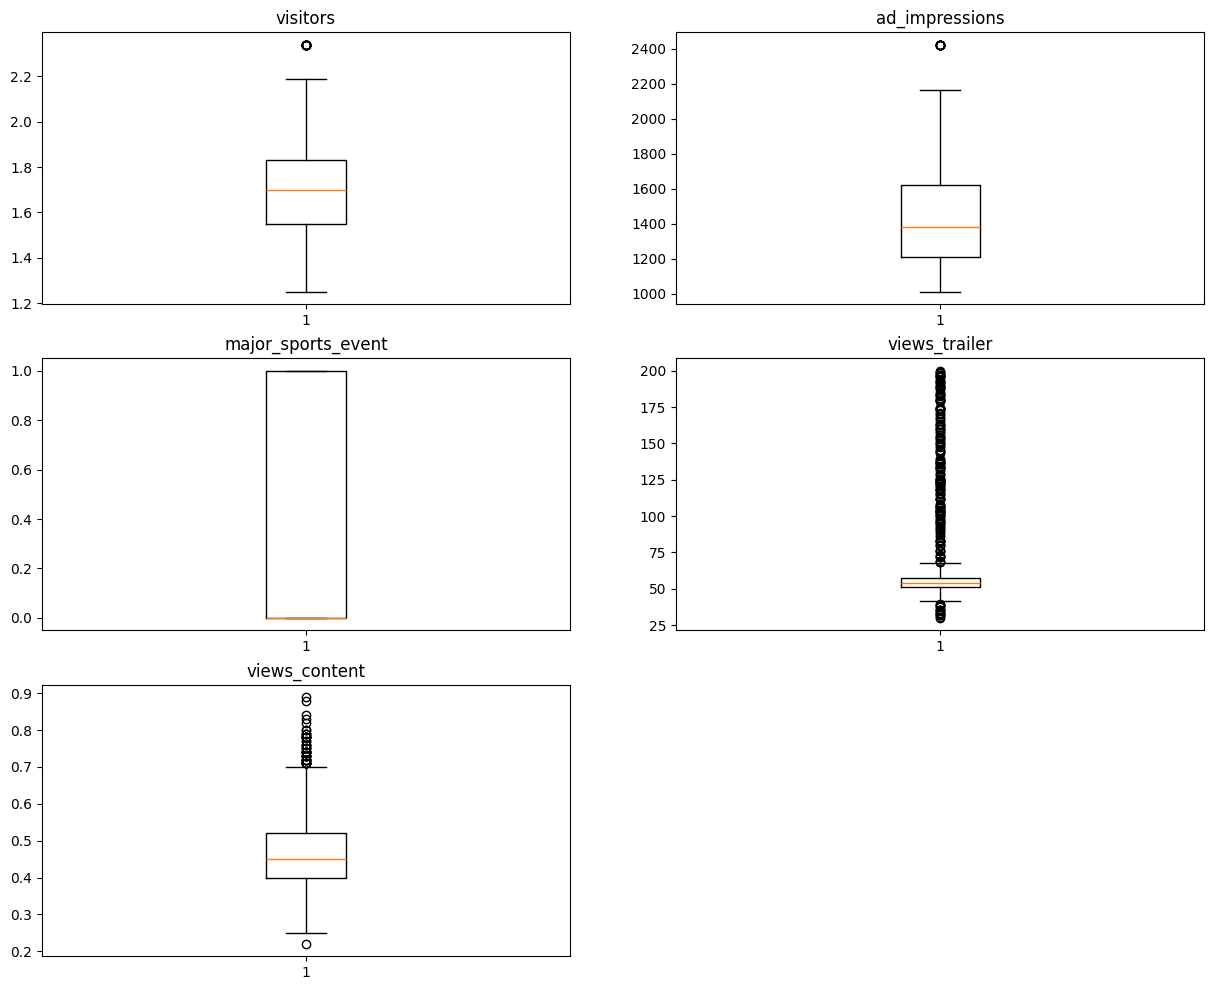

In [ ]:
# Let's look to see if there are problematic outliers in our numeric columns because outliers can significantly impact our regression model:

numeric_columns = ["visitors", "ad_impressions", "major_sports_event", "views_trailer", "views_content"]

plt.figure(figsize=(15,12))

for i, variable in enumerate(numeric_columns):
  plt.subplot(3, 2, i + 1)
  plt.boxplot(dataset[variable], whis = 1.5)
  plt.tight_layout
  plt.title(variable)

plt.show()

In [ ]:
# From the above boxplots, we can see visitors and ad_impressions have an outlier each while views_trailer and views_content have a lot.
# For views_trailer and views_content, I think the outlers might in fact be valid because it is very possible that some content pieces significantly outperform what we usually see. So let's leave this untouched.
# For visitors, it stands to reason that a particular week might've had a holiday and therefore saw a spike in visitors to the OTT service, so this also seems valid.
# Lastly, for ad_impressions, it might've been the case that a higher budget was allocated to a certain content piece and therefore resulted in higher ad impressions. So we will leave this untouched as well.

# Overall, while we do see outliers on some columns, all of them seem very valid, and we will therefore leave them be in our analysis moving forward.

In [ ]:
# Now, let's start creating dummy variables for columns that contain discrete string objects since they can't be directly used in regression. Those are: "genre", "dayofweek", and "season".

# Let's start with genre. First, let's look at how many unique entries it has:

dataset["genre"].unique()

# We can see it has 8 unique entries. We will then need to create 8 dummy columns and drop 1 because if the genre isnt one of the first 7, then that would automatically imply it is the 8th.

array(['Horror', 'Thriller', 'Sci-Fi', 'Others', 'Drama', 'Action',
       'Comedy', 'Romance'], dtype=object)

In [ ]:
# Creating dummies for the "genre" column and adding them to the dataset:

dataset_rg = pd.get_dummies (dataset, columns=["genre"])

dataset_rg.head()

,visitors,ad_impressions,major_sports_event,dayofweek,season,views_trailer,views_content,genre_Action,genre_Comedy,genre_Drama,genre_Horror,genre_Others,genre_Romance,genre_Sci-Fi,genre_Thriller
0,1.67,1113.81,0,Wednesday,Spring,56.70,0.51,False,False,False,True,False,False,False,False
1,1.46,1498.41,1,Friday,Fall,52.69,0.32,False,False,False,False,False,False,False,True
2,1.47,1079.19,1,Wednesday,Fall,48.74,0.39,False,False,False,False,False,False,False,True
3,1.85,1342.77,1,Friday,Fall,49.81,0.44,False,False,False,False,False,False,True,False
4,1.46,1498.41,0,Sunday,Winter,55.83,0.46,False,False,False,False,False,False,True,False


In [ ]:
# Now let's drop the "genre_Others" column:

dataset_rg.drop ("genre_Others", axis=1, inplace=True)

dataset_rg.head()

,visitors,ad_impressions,major_sports_event,dayofweek,season,views_trailer,views_content,genre_Action,genre_Comedy,genre_Drama,genre_Horror,genre_Romance,genre_Sci-Fi,genre_Thriller
0,1.67,1113.81,0,Wednesday,Spring,56.70,0.51,False,False,False,True,False,False,False
1,1.46,1498.41,1,Friday,Fall,52.69,0.32,False,False,False,False,False,False,True
2,1.47,1079.19,1,Wednesday,Fall,48.74,0.39,False,False,False,False,False,False,True
3,1.85,1342.77,1,Friday,Fall,49.81,0.44,False,False,False,False,False,True,False
4,1.46,1498.41,0,Sunday,Winter,55.83,0.46,False,False,False,False,False,True,False


In [ ]:
# Now lets take a look at our dataset at a glance again:
# We can see the genres column has been replaced with the dummies we created.
# Although, the datatype is boolean and we want it to be an integer.

dataset_rg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   visitors            1000 non-null   float64
 1   ad_impressions      1000 non-null   float64
 2   major_sports_event  1000 non-null   int64  
 3   dayofweek           1000 non-null   object 
 4   season              1000 non-null   object 
 5   views_trailer       1000 non-null   float64
 6   views_content       1000 non-null   float64
 7   genre_Action        1000 non-null   bool   
 8   genre_Comedy        1000 non-null   bool   
 9   genre_Drama         1000 non-null   bool   
 10  genre_Horror        1000 non-null   bool   
 11  genre_Romance       1000 non-null   bool   
 12  genre_Sci-Fi        1000 non-null   bool   
 13  genre_Thriller      1000 non-null   bool   
dtypes: bool(7), float64(4), int64(1), object(2)
memory usage: 61.7+ KB


In [ ]:
# Let's convert the boolean datatype of the dummy columns to integer datatype:

dataset_rg.iloc [:, 7:] = dataset_rg.iloc [:, 7:].astype(int)

dataset_rg.info()

# Datatypes seem ok.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   visitors            1000 non-null   float64
 1   ad_impressions      1000 non-null   float64
 2   major_sports_event  1000 non-null   int64  
 3   dayofweek           1000 non-null   object 
 4   season              1000 non-null   object 
 5   views_trailer       1000 non-null   float64
 6   views_content       1000 non-null   float64
 7   genre_Action        1000 non-null   int64  
 8   genre_Comedy        1000 non-null   int64  
 9   genre_Drama         1000 non-null   int64  
 10  genre_Horror        1000 non-null   int64  
 11  genre_Romance       1000 non-null   int64  
 12  genre_Sci-Fi        1000 non-null   int64  
 13  genre_Thriller      1000 non-null   int64  
dtypes: float64(4), int64(8), object(2)
memory usage: 109.5+ KB


/tmp/ipython-input-1180/3828793982.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0      0
1      0
2      0
3      0
4      0
      ..
995    0
996    1
997    0
998    0
999    0
Name: genre_Action, Length: 1000, dtype: int64' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  dataset_rg.iloc [:, 7:] = dataset_rg.iloc [:, 7:].astype(int)
/tmp/ipython-input-1180/3828793982.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0      0
1      0
2      0
3      0
4      0
      ..
995    0
996    0
997    0
998    0
999    1
Name: genre_Comedy, Length: 1000, dtype: int64' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  dataset_rg.iloc [:, 7:] = dataset_rg.iloc [:, 7:].astype(int)
/tmp/ipython-input-1180/3828793982.py:3: FutureWarning: Setting an item of incompatible 

In [ ]:
dataset_rg.head()

,visitors,ad_impressions,major_sports_event,dayofweek,season,views_trailer,views_content,genre_Action,genre_Comedy,genre_Drama,genre_Horror,genre_Romance,genre_Sci-Fi,genre_Thriller
0,1.67,1113.81,0,Wednesday,Spring,56.70,0.51,0,0,0,1,0,0,0
1,1.46,1498.41,1,Friday,Fall,52.69,0.32,0,0,0,0,0,0,1
2,1.47,1079.19,1,Wednesday,Fall,48.74,0.39,0,0,0,0,0,0,1
3,1.85,1342.77,1,Friday,Fall,49.81,0.44,0,0,0,0,0,1,0
4,1.46,1498.41,0,Sunday,Winter,55.83,0.46,0,0,0,0,0,1,0


In [ ]:
# Great, now let's repeat the process to create dummies for our second column: dayofweek.

dataset_rg = pd.get_dummies (dataset_rg, columns = ["dayofweek"])

In [ ]:
dataset_rg.head()

,visitors,ad_impressions,major_sports_event,season,views_trailer,views_content,genre_Action,genre_Comedy,genre_Drama,genre_Horror,genre_Romance,genre_Sci-Fi,genre_Thriller,dayofweek_Friday,dayofweek_Monday,dayofweek_Saturday,dayofweek_Sunday,dayofweek_Thursday,dayofweek_Tuesday,dayofweek_Wednesday
0,1.67,1113.81,0,Spring,56.70,0.51,0,0,0,1,0,0,0,False,False,False,False,False,False,True
1,1.46,1498.41,1,Fall,52.69,0.32,0,0,0,0,0,0,1,True,False,False,False,False,False,False
2,1.47,1079.19,1,Fall,48.74,0.39,0,0,0,0,0,0,1,False,False,False,False,False,False,True
3,1.85,1342.77,1,Fall,49.81,0.44,0,0,0,0,0,1,0,True,False,False,False,False,False,False
4,1.46,1498.41,0,Winter,55.83,0.46,0,0,0,0,0,1,0,False,False,False,True,False,False,False


In [ ]:
# Let's drop the column for sunday, as the other columns are sufficient for that information.

dataset_rg.drop ("dayofweek_Sunday", axis = 1, inplace = True)

In [ ]:
# Let's look at the info now, we see the dummies have been created but the datatype is boolean. Let's fix that.

dataset_rg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   visitors             1000 non-null   float64
 1   ad_impressions       1000 non-null   float64
 2   major_sports_event   1000 non-null   int64  
 3   season               1000 non-null   object 
 4   views_trailer        1000 non-null   float64
 5   views_content        1000 non-null   float64
 6   genre_Action         1000 non-null   int64  
 7   genre_Comedy         1000 non-null   int64  
 8   genre_Drama          1000 non-null   int64  
 9   genre_Horror         1000 non-null   int64  
 10  genre_Romance        1000 non-null   int64  
 11  genre_Sci-Fi         1000 non-null   int64  
 12  genre_Thriller       1000 non-null   int64  
 13  dayofweek_Friday     1000 non-null   bool   
 14  dayofweek_Monday     1000 non-null   bool   
 15  dayofweek_Saturday   1000 non-null   bo

In [ ]:
# Changing boolean datatype to integer:

dataset_rg.iloc [:, 13:] = dataset_rg.iloc [:, 13:].astype(int)

dataset_rg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   visitors             1000 non-null   float64
 1   ad_impressions       1000 non-null   float64
 2   major_sports_event   1000 non-null   int64  
 3   season               1000 non-null   object 
 4   views_trailer        1000 non-null   float64
 5   views_content        1000 non-null   float64
 6   genre_Action         1000 non-null   int64  
 7   genre_Comedy         1000 non-null   int64  
 8   genre_Drama          1000 non-null   int64  
 9   genre_Horror         1000 non-null   int64  
 10  genre_Romance        1000 non-null   int64  
 11  genre_Sci-Fi         1000 non-null   int64  
 12  genre_Thriller       1000 non-null   int64  
 13  dayofweek_Friday     1000 non-null   int64  
 14  dayofweek_Monday     1000 non-null   int64  
 15  dayofweek_Saturday   1000 non-null   in

/tmp/ipython-input-1180/745097900.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0      0
1      1
2      0
3      1
4      0
      ..
995    1
996    1
997    0
998    0
999    0
Name: dayofweek_Friday, Length: 1000, dtype: int64' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  dataset_rg.iloc [:, 13:] = dataset_rg.iloc [:, 13:].astype(int)
/tmp/ipython-input-1180/745097900.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0      0
1      0
2      0
3      0
4      0
      ..
995    0
996    0
997    0
998    1
999    0
Name: dayofweek_Monday, Length: 1000, dtype: int64' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  dataset_rg.iloc [:, 13:] = dataset_rg.iloc [:, 13:].astype(int)
/tmp/ipython-input-1180/745097900.py:3: FutureWarning: Setting an item of inco

In [ ]:
# Perfect. Lastly, let's repeat the process for the remaining column: season.

dataset_rg = pd.get_dummies (dataset_rg, columns = ["season"], drop_first=True)

In [ ]:
dataset_rg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   visitors             1000 non-null   float64
 1   ad_impressions       1000 non-null   float64
 2   major_sports_event   1000 non-null   int64  
 3   views_trailer        1000 non-null   float64
 4   views_content        1000 non-null   float64
 5   genre_Action         1000 non-null   int64  
 6   genre_Comedy         1000 non-null   int64  
 7   genre_Drama          1000 non-null   int64  
 8   genre_Horror         1000 non-null   int64  
 9   genre_Romance        1000 non-null   int64  
 10  genre_Sci-Fi         1000 non-null   int64  
 11  genre_Thriller       1000 non-null   int64  
 12  dayofweek_Friday     1000 non-null   int64  
 13  dayofweek_Monday     1000 non-null   int64  
 14  dayofweek_Saturday   1000 non-null   int64  
 15  dayofweek_Thursday   1000 non-null   in

In [ ]:
dataset_rg.iloc [:, 18:] = dataset_rg.iloc [:, 18:].astype(int)

dataset_rg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   visitors             1000 non-null   float64
 1   ad_impressions       1000 non-null   float64
 2   major_sports_event   1000 non-null   int64  
 3   views_trailer        1000 non-null   float64
 4   views_content        1000 non-null   float64
 5   genre_Action         1000 non-null   int64  
 6   genre_Comedy         1000 non-null   int64  
 7   genre_Drama          1000 non-null   int64  
 8   genre_Horror         1000 non-null   int64  
 9   genre_Romance        1000 non-null   int64  
 10  genre_Sci-Fi         1000 non-null   int64  
 11  genre_Thriller       1000 non-null   int64  
 12  dayofweek_Friday     1000 non-null   int64  
 13  dayofweek_Monday     1000 non-null   int64  
 14  dayofweek_Saturday   1000 non-null   int64  
 15  dayofweek_Thursday   1000 non-null   in

/tmp/ipython-input-1180/1780129482.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0      1
1      0
2      0
3      0
4      0
      ..
995    0
996    0
997    0
998    0
999    0
Name: season_Spring, Length: 1000, dtype: int64' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  dataset_rg.iloc [:, 18:] = dataset_rg.iloc [:, 18:].astype(int)
/tmp/ipython-input-1180/1780129482.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0      0
1      0
2      0
3      0
4      0
      ..
995    0
996    1
997    0
998    1
999    1
Name: season_Summer, Length: 1000, dtype: int64' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  dataset_rg.iloc [:, 18:] = dataset_rg.iloc [:, 18:].astype(int)
/tmp/ipython-input-1180/1780129482.py:1: FutureWarning: Setting an item of incompa

In [ ]:
# Now that our dataset seems fine, let's split it into two sets, one for training our regression model and another for testing it:

# splitting dependent and independent variables and adding a constant to the independent variables:

y = dataset_rg ["views_content"]
x = dataset_rg.drop ("views_content", axis = 1)
x = sm.add_constant (x)


# Splitting into training and testing sets:

x_train, x_test, y_train, y_test = train_test_split (x, y, test_size = 0.30, random_state = 1)

x_train.head()


,const,visitors,ad_impressions,major_sports_event,views_trailer,genre_Action,genre_Comedy,genre_Drama,genre_Horror,genre_Romance,...,genre_Thriller,dayofweek_Friday,dayofweek_Monday,dayofweek_Saturday,dayofweek_Thursday,dayofweek_Tuesday,dayofweek_Wednesday,season_Spring,season_Summer,season_Winter
731,1.0,1.64,1992.53,0,49.62,0,0,1,0,0,...,0,1,0,0,0,0,0,0,1,0
716,1.0,1.69,2158.03,0,132.93,0,0,0,0,0,...,1,0,0,0,0,0,1,0,0,1
640,1.0,1.47,1229.35,0,54.13,0,0,0,0,0,...,0,1,0,0,0,0,0,0,1,0
804,1.0,1.49,1010.87,0,106.62,0,0,0,1,0,...,0,0,0,0,0,0,1,0,0,0
737,1.0,2.19,1119.90,0,52.04,0,0,0,0,0,...,0,0,0,0,0,0,1,1,0,0


In [ ]:
x_test.head()

,const,visitors,ad_impressions,major_sports_event,views_trailer,genre_Action,genre_Comedy,genre_Drama,genre_Horror,genre_Romance,...,genre_Thriller,dayofweek_Friday,dayofweek_Monday,dayofweek_Saturday,dayofweek_Thursday,dayofweek_Tuesday,dayofweek_Wednesday,season_Spring,season_Summer,season_Winter
507,1.0,1.58,1323.74,0,57.85,0,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
818,1.0,1.54,2122.33,0,56.82,1,0,0,0,0,...,0,0,0,0,1,0,0,1,0,0
452,1.0,1.82,1152.29,0,165.58,0,1,0,0,0,...,0,1,0,0,0,0,0,0,0,0
368,1.0,2.03,1145.37,0,59.99,0,0,0,0,0,...,0,1,0,0,0,0,0,1,0,0
242,1.0,1.75,1060.86,0,58.99,0,0,0,0,0,...,1,1,0,0,0,0,0,0,1,0


In [ ]:
y_train.head()

,views_content
731,0.40
716,0.70
640,0.42
804,0.55
737,0.59


In [ ]:
y_test.head()

,views_content
507,0.43
818,0.45
452,0.63
368,0.50
242,0.50


In [ ]:
# Great, now our data is ready for exploratory data analysis and further down, regression.

## **Exploratory Data Analysis**

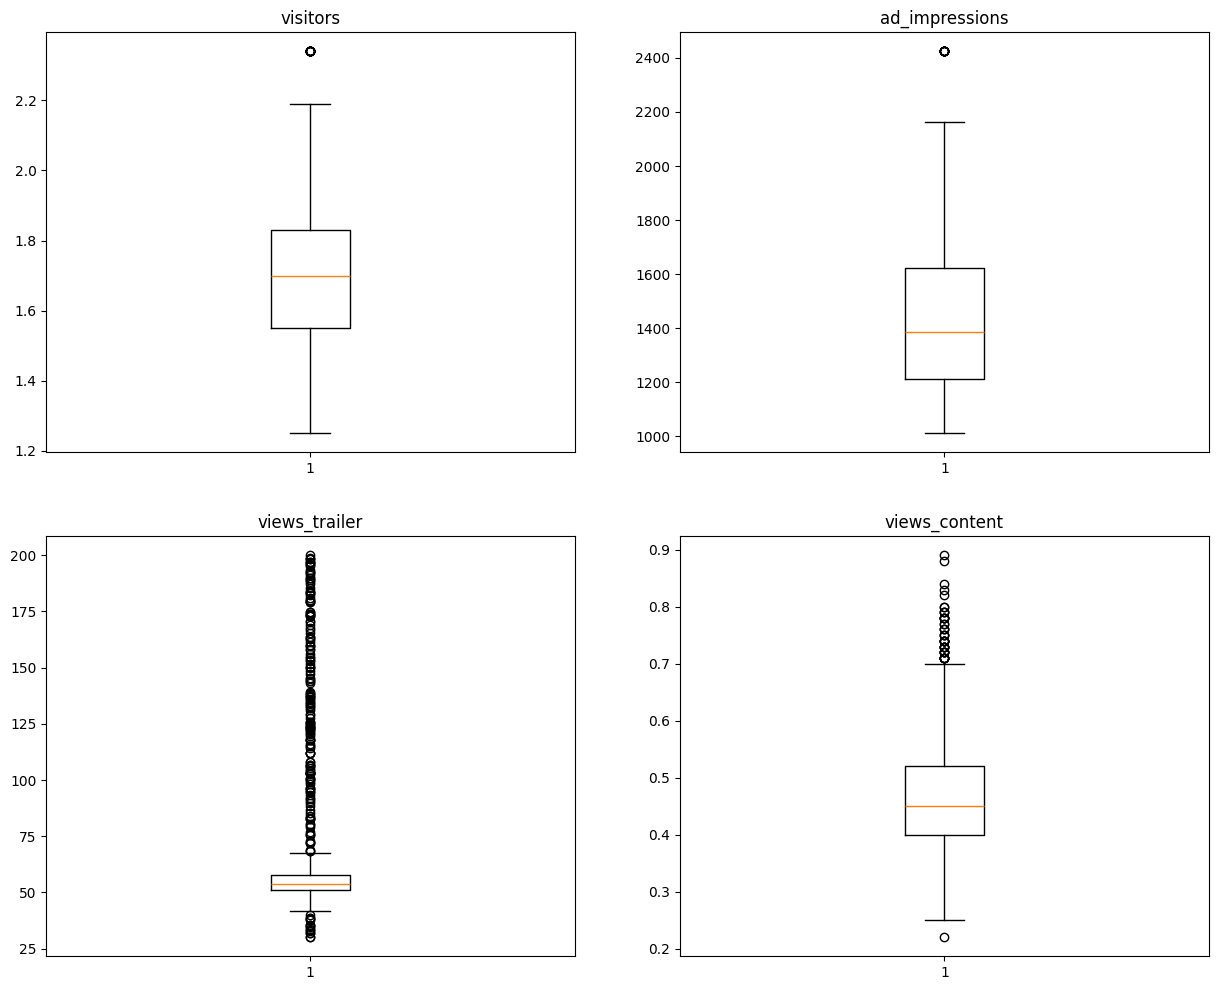

In [ ]:
# Let's start with Univariate Analysis.

# Let's look at a boxplot of each continuous variable to get a sense for its distribution:

continuous_variables = ["visitors", "ad_impressions", "views_trailer", "views_content"]

plt.figure(figsize=(15,12))

for i, variable in enumerate(continuous_variables):
  plt.subplot(2, 2, i + 1)
  plt.boxplot(dataset[variable], whis = 1.5)
  plt.tight_layout
  plt.title(variable)

plt.show()

- As we had previously noted when preparing the data, there are outliers in all of the continuous variables as we see here in the box plots.
- As we had previously observed as well, these outliers don't seem to be errors or problematic in any other way.

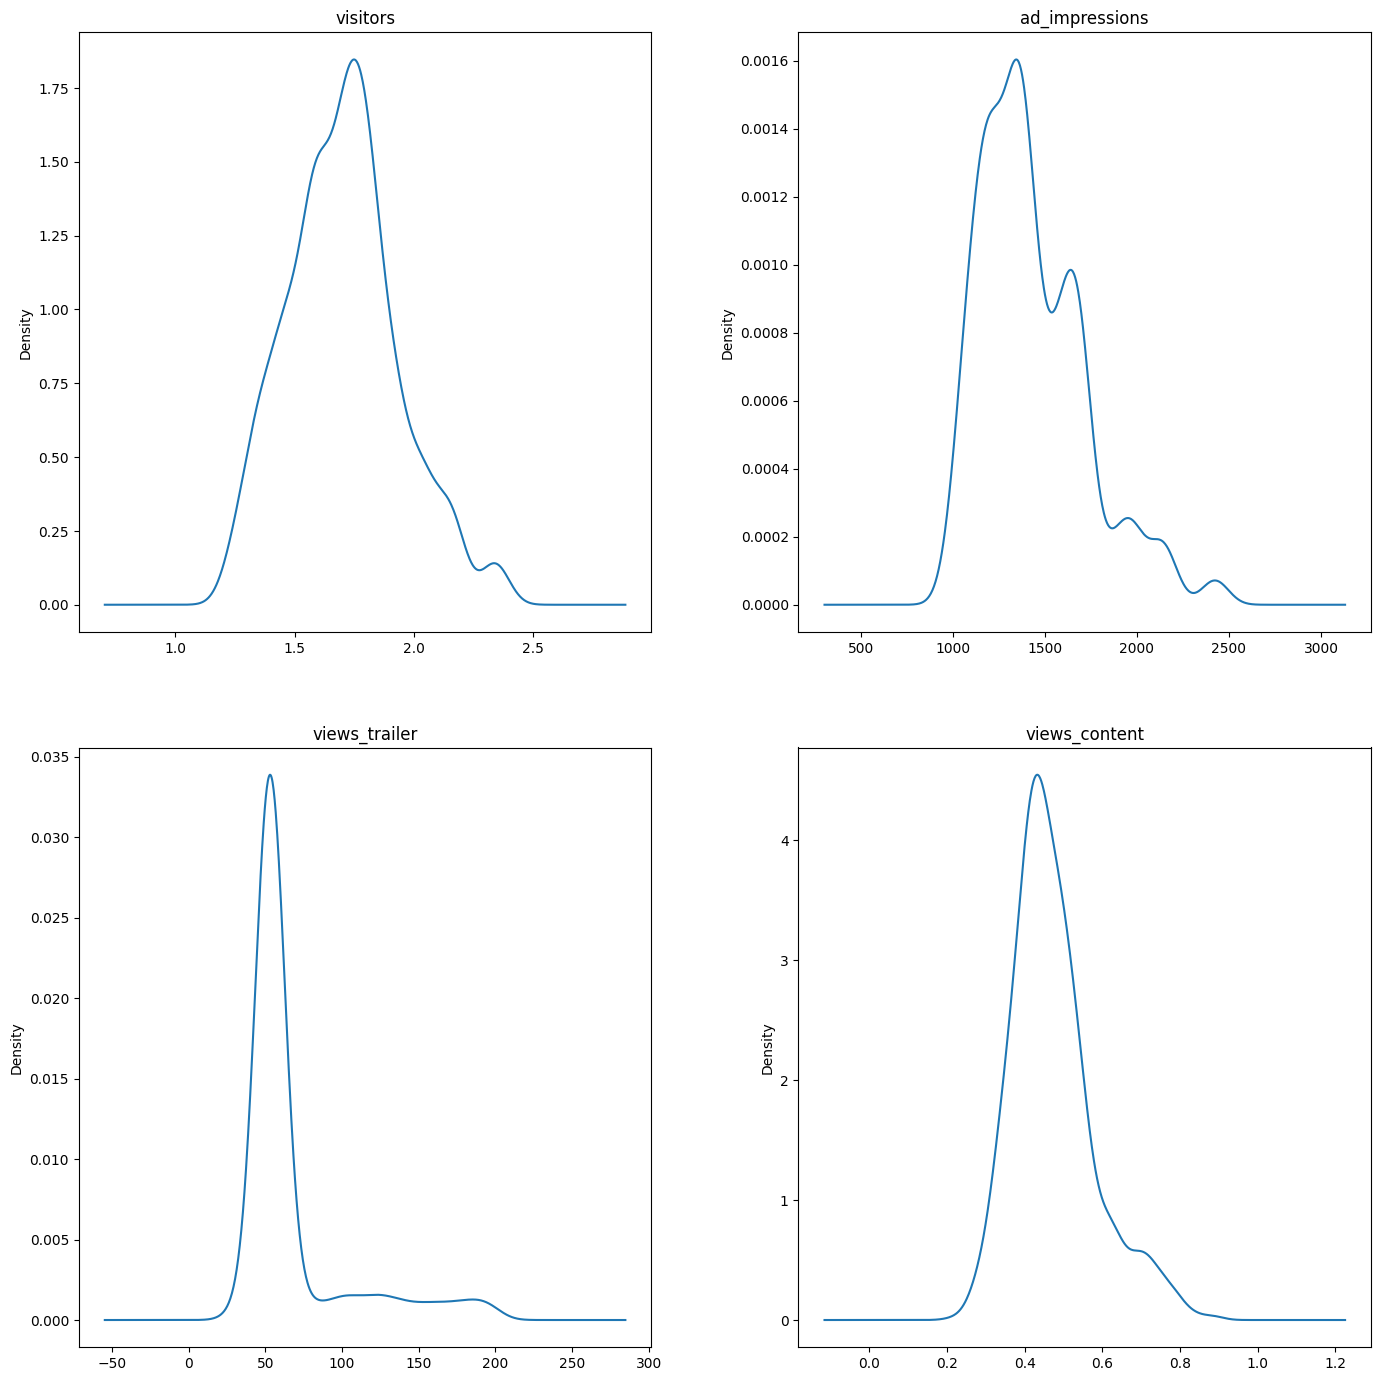

In [ ]:
# Now let's look at the frequency distributions of all these continuous variables:

plt.figure(figsize=(15,15))

for i, variable in enumerate(continuous_variables):
  plt.subplot(2, 2, i + 1)
  dataset[variable].plot(kind = "kde")
  plt.tight_layout (pad = 5)
  plt.title(variable)

plt.show()

- Reflecting what we had seen about the outliers from the above boxplots, we see the same skewing happening because of the outliers in the frequency distribution plots as well.
- All of them appear to start low, peak somewhere in the middle, then drop as magnitude of entry goes up. In this sense, they resemble the trend of a normal distribution, but otherwise, they don't appear normal.

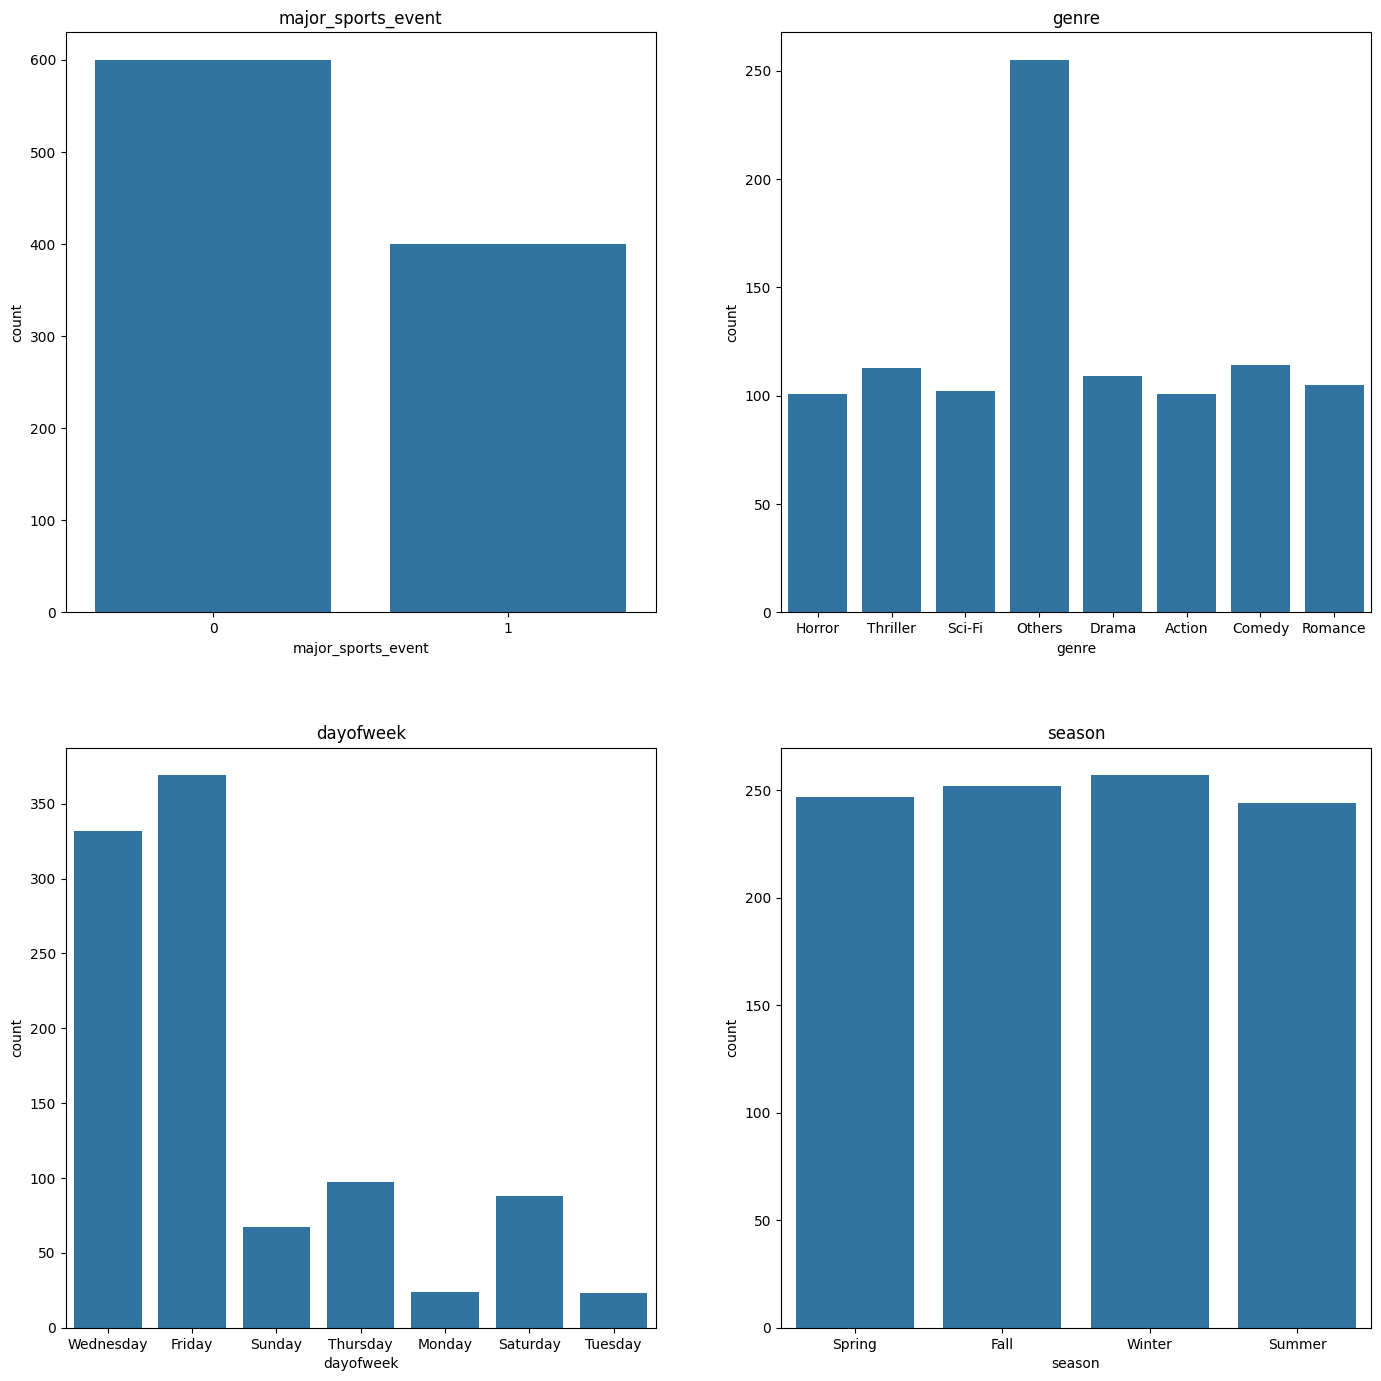

In [ ]:
# Now that we've gotten a sense for the distribution of the continuous variables in our dataset, let's look at those of our discrete variables:

discrete_variables = ["major_sports_event", "genre", "dayofweek", "season"]

plt.figure(figsize=(15,15))

for i, variable in enumerate(discrete_variables):
  plt.subplot(2, 2, i + 1)
  sns.countplot(data = dataset, x = dataset[variable])
  plt.tight_layout (pad = 5)
  plt.title(variable)

plt.show()

- There is a pattern that jumps out from each of these bar graphs.
- Firstly, the days on which there were no major sporting events were a lot more than those where there were.
- Second, all genres seem approximately equally popular, while the ones that are clubbed into the "other" category account for a lot more content than any single genre.
- Third, a lot of content was released either on Wednesdays or on Fridays by a significant margin as compared to the other days of the week.
- Lastly, the release of content across the different seasons of the year seem rather consistent.

<Figure size 1500x1500 with 0 Axes>

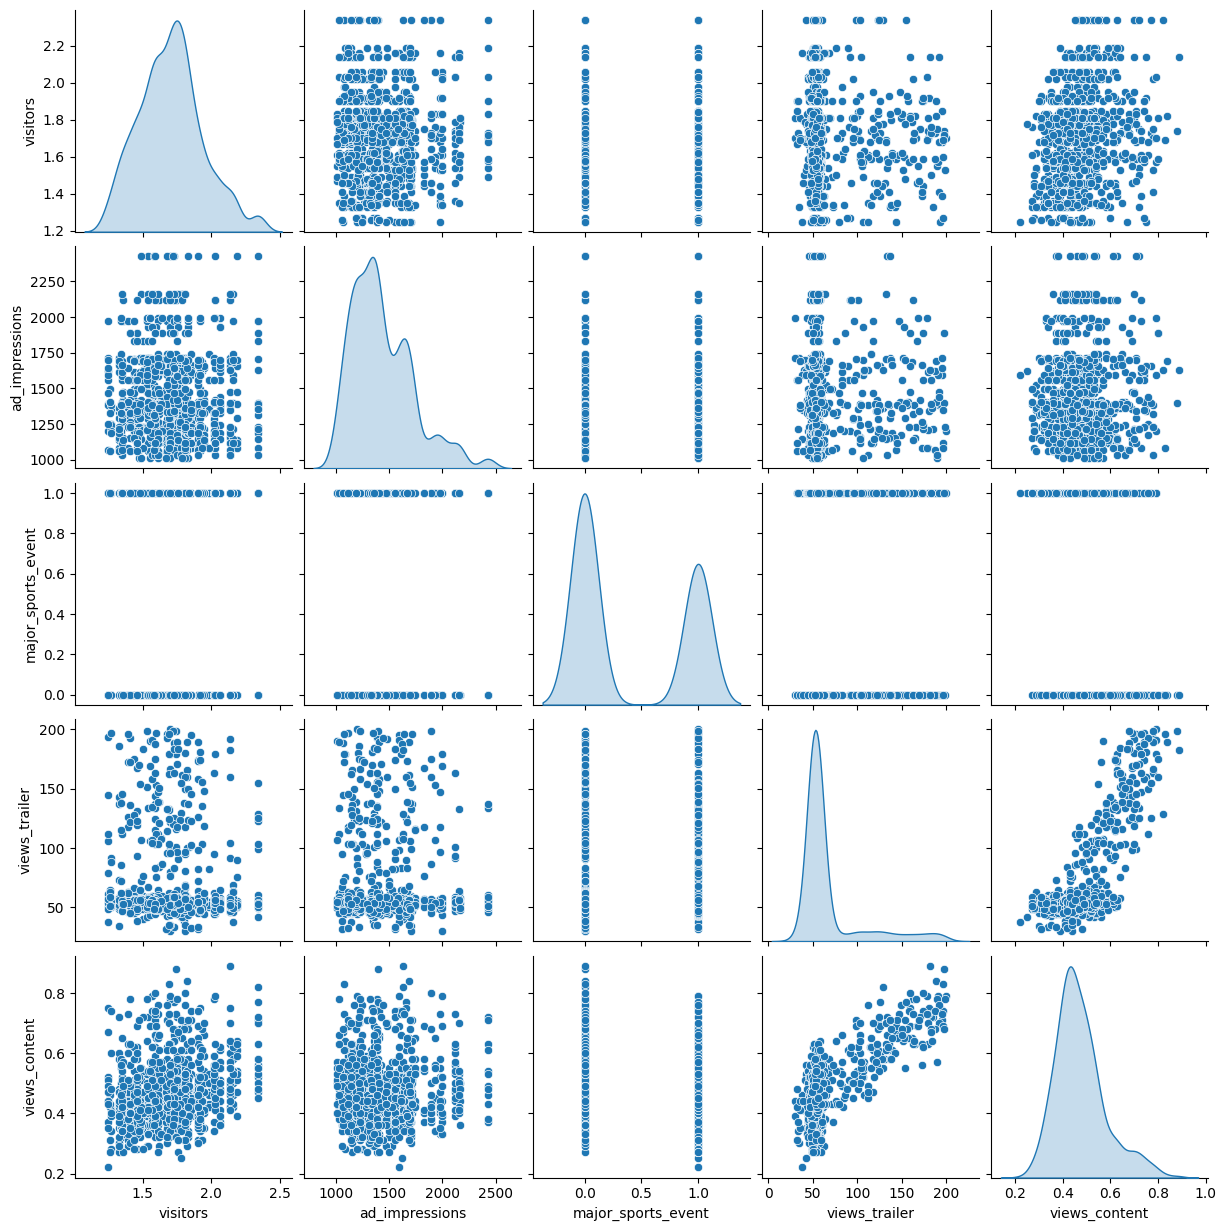

In [ ]:
# Now let's move onto Bivariate Analysis. Let's start with looking at the numeric variables against one another:

plt.figure(figsize=(15,15))
sns.pairplot (dataset, diag_kind="kde")
plt.show()

- We see something very interesting here.
- "views_content" is our variable of interest that we are trying to predict (dependant variable). This "views_content" doesn't seem to have a linear relationship with any other numerical variable at all except for the "views_trailer" variable.
- This means our assumptions for performing linear regression might be violated for every dependant numerical variable except maybe for the "views_trailer" variable. We will look at this in greater depth later when we perform the regression.

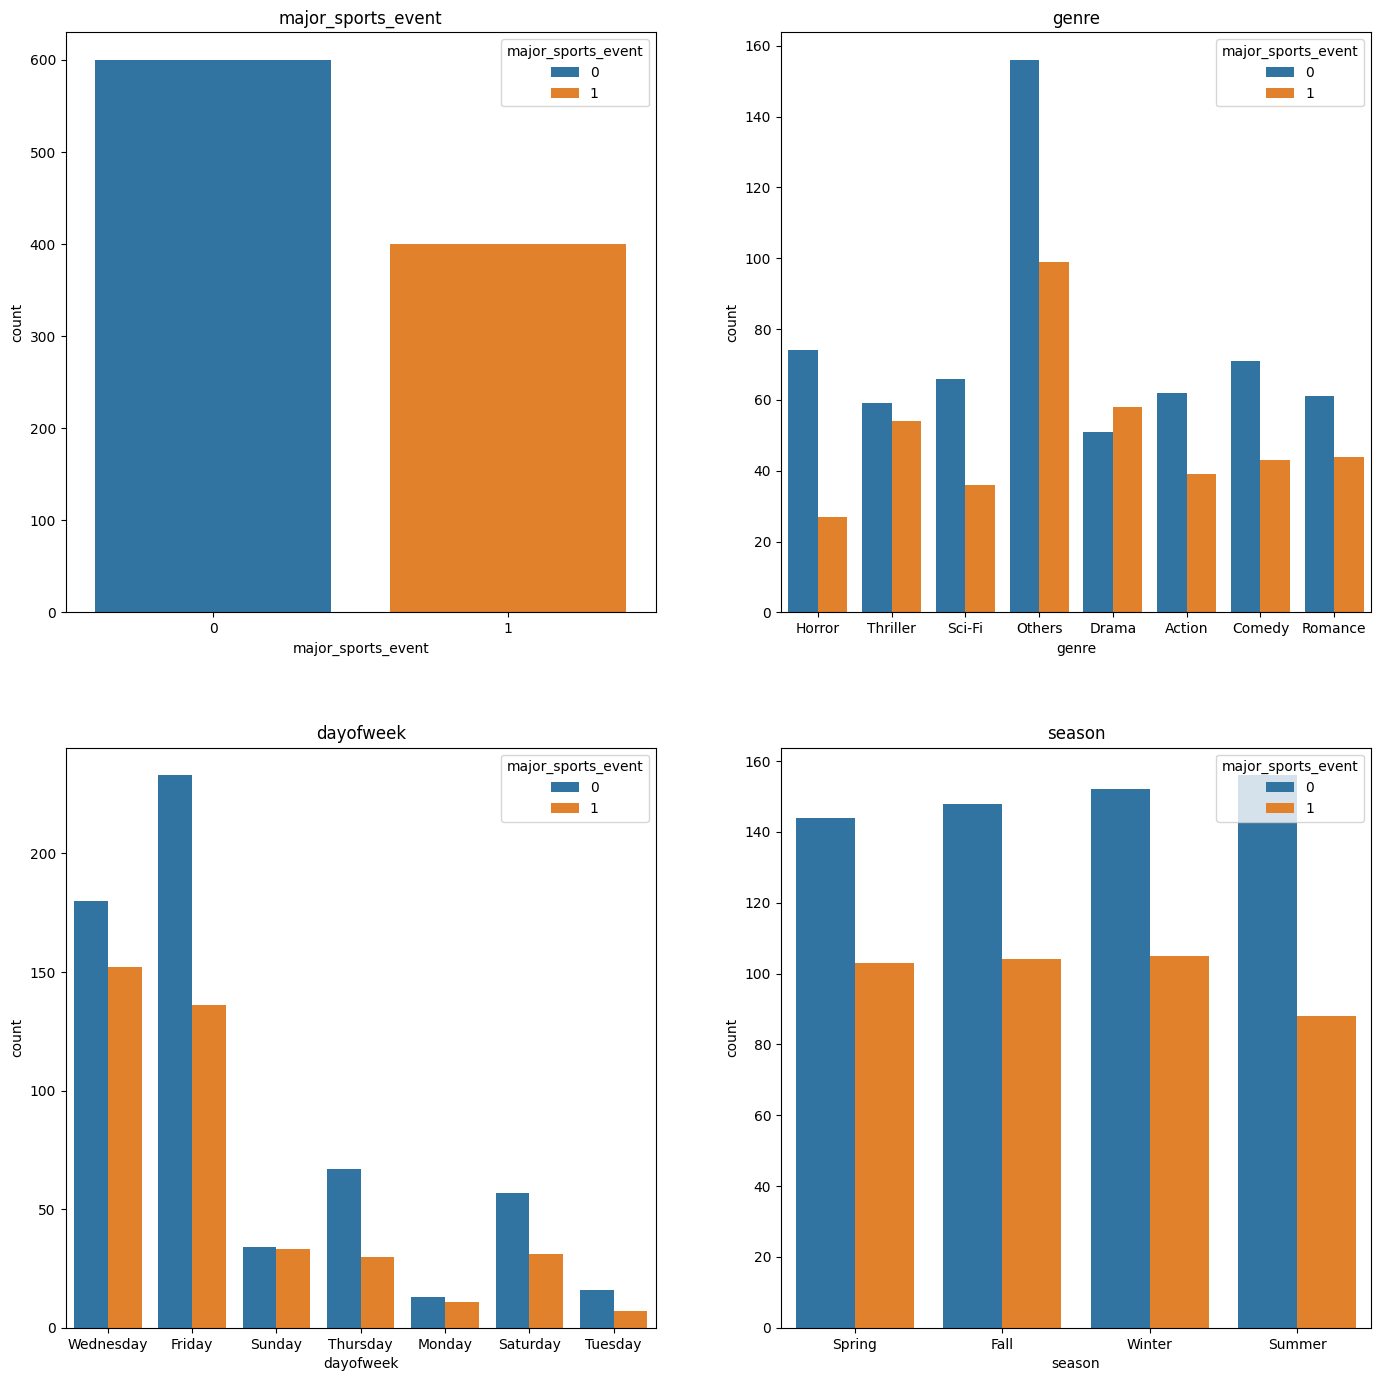

In [ ]:
# Next let's look at discrete variables against one another:

plt.figure(figsize=(15,15))

for i, variable in enumerate(discrete_variables):
  plt.subplot(2, 2, i + 1)
  sns.countplot(data = dataset, x = dataset[variable], hue = "major_sports_event")
  plt.tight_layout (pad = 5)
  plt.title(variable)

plt.show()

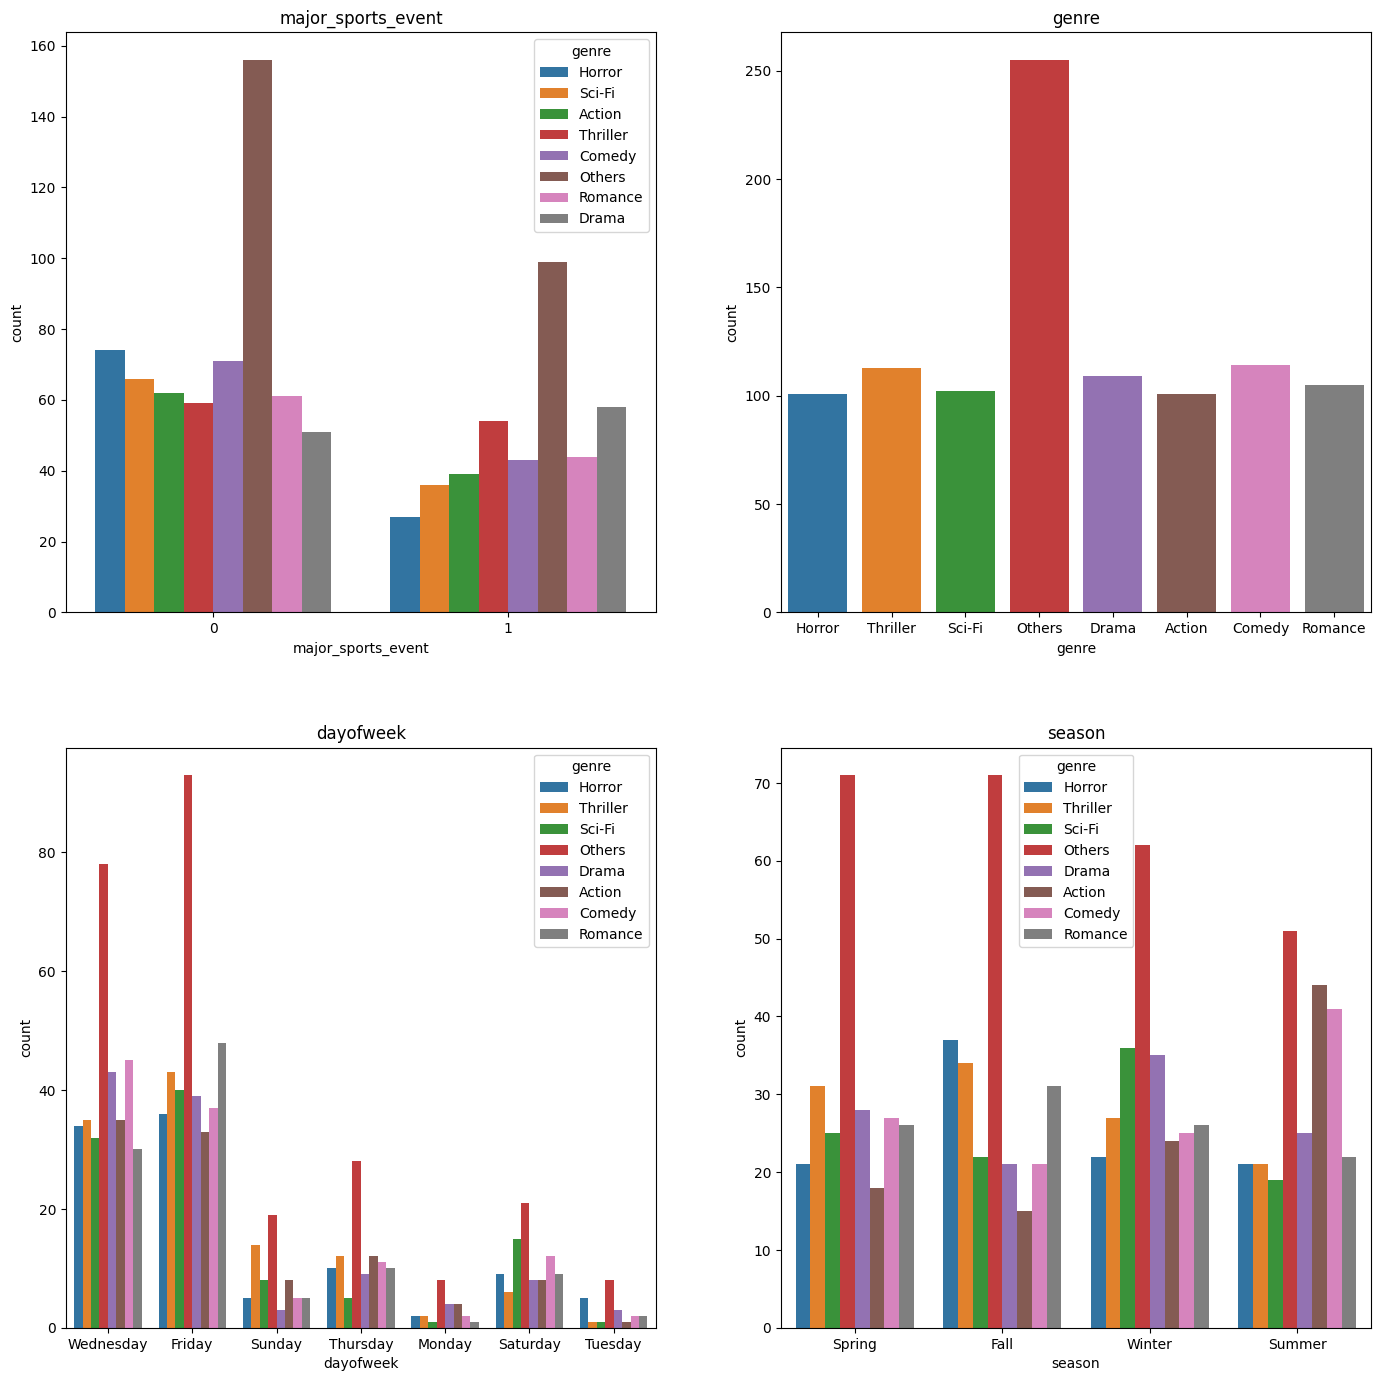

In [ ]:
plt.figure(figsize=(15,15))

for i, variable in enumerate(discrete_variables):
  plt.subplot(2, 2, i + 1)
  sns.countplot(data = dataset, x = dataset[variable], hue = "genre")
  plt.tight_layout (pad = 5)
  plt.title(variable)

plt.show()

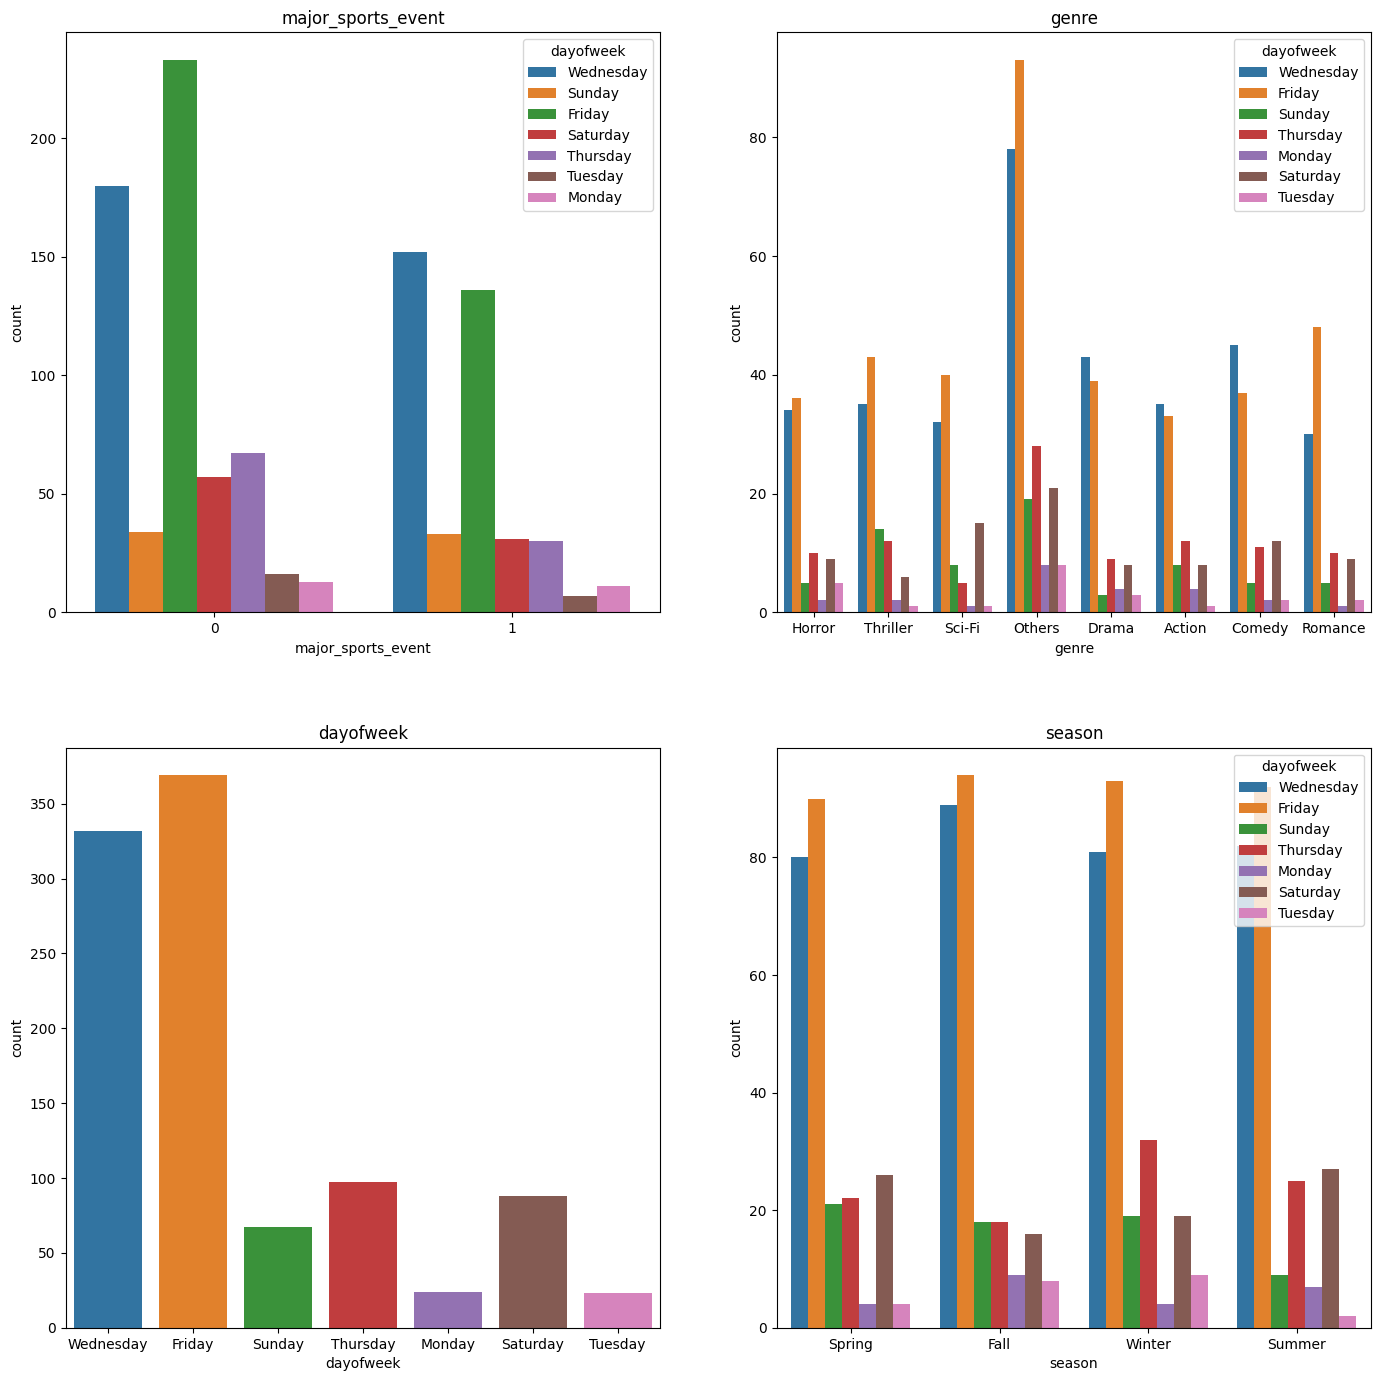

In [ ]:
plt.figure(figsize=(15,15))

for i, variable in enumerate(discrete_variables):
  plt.subplot(2, 2, i + 1)
  sns.countplot(data = dataset, x = dataset[variable], hue = "dayofweek")
  plt.tight_layout (pad = 5)
  plt.title(variable)

plt.show()

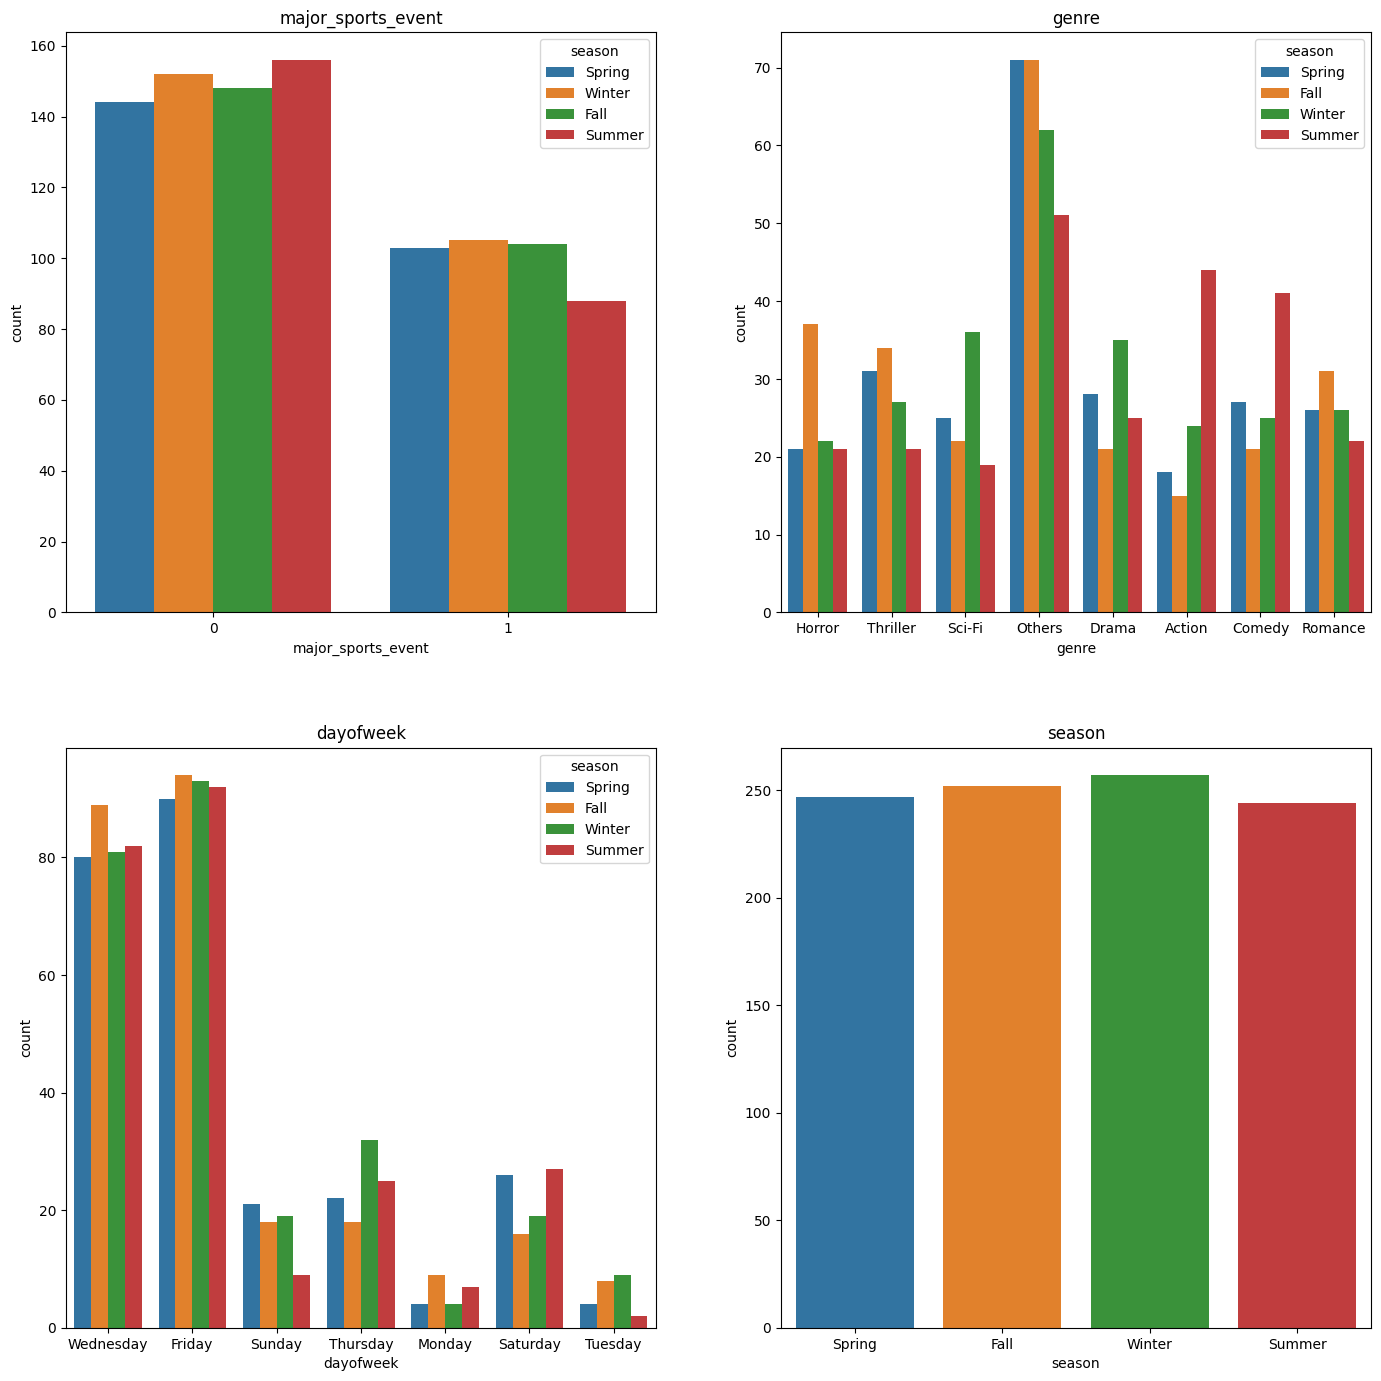

In [ ]:
plt.figure(figsize=(15,15))

for i, variable in enumerate(discrete_variables):
  plt.subplot(2, 2, i + 1)
  sns.countplot(data = dataset, x = dataset[variable], hue = "season")
  plt.tight_layout (pad = 5)
  plt.title(variable)

plt.show()

- When we look at each discrete variable broken down by the "major_sports_event" variable, we don't see any particular pattern stand out. Given that viewership is higher on days where there was no major sports event in general, we also see the same play out in the breakdowns as well. So nothing surprising or noteworthy here.
- Next, the breakdowns by the "genre" and "dayofweek" variables. Again, nothing shows up that is not expected. We already know Wednesdays and Fridays have the most viewership, so it is unsurprising that the breakdowns also reflect that. The "others" category in the genres variable has the most viewership, and that too reflects in the breakdowns.
- Lastly, the breakdowns by the "season" variable. Over here too for the most part, there isn't anything unsurprising. Although, we do see something interesting within the breakdown of the "genre" variable by the "season" variable though. Certain genres seem to be particularly more popular in certain seasons. For example, Action and Comedy are more popular in Summer, Drama and Sci-Fi are more popular in Winter, and Horror is more popular in Fall. That being said, the influence doesn't seem to be that pronounced that it might interefere with our regression later on.

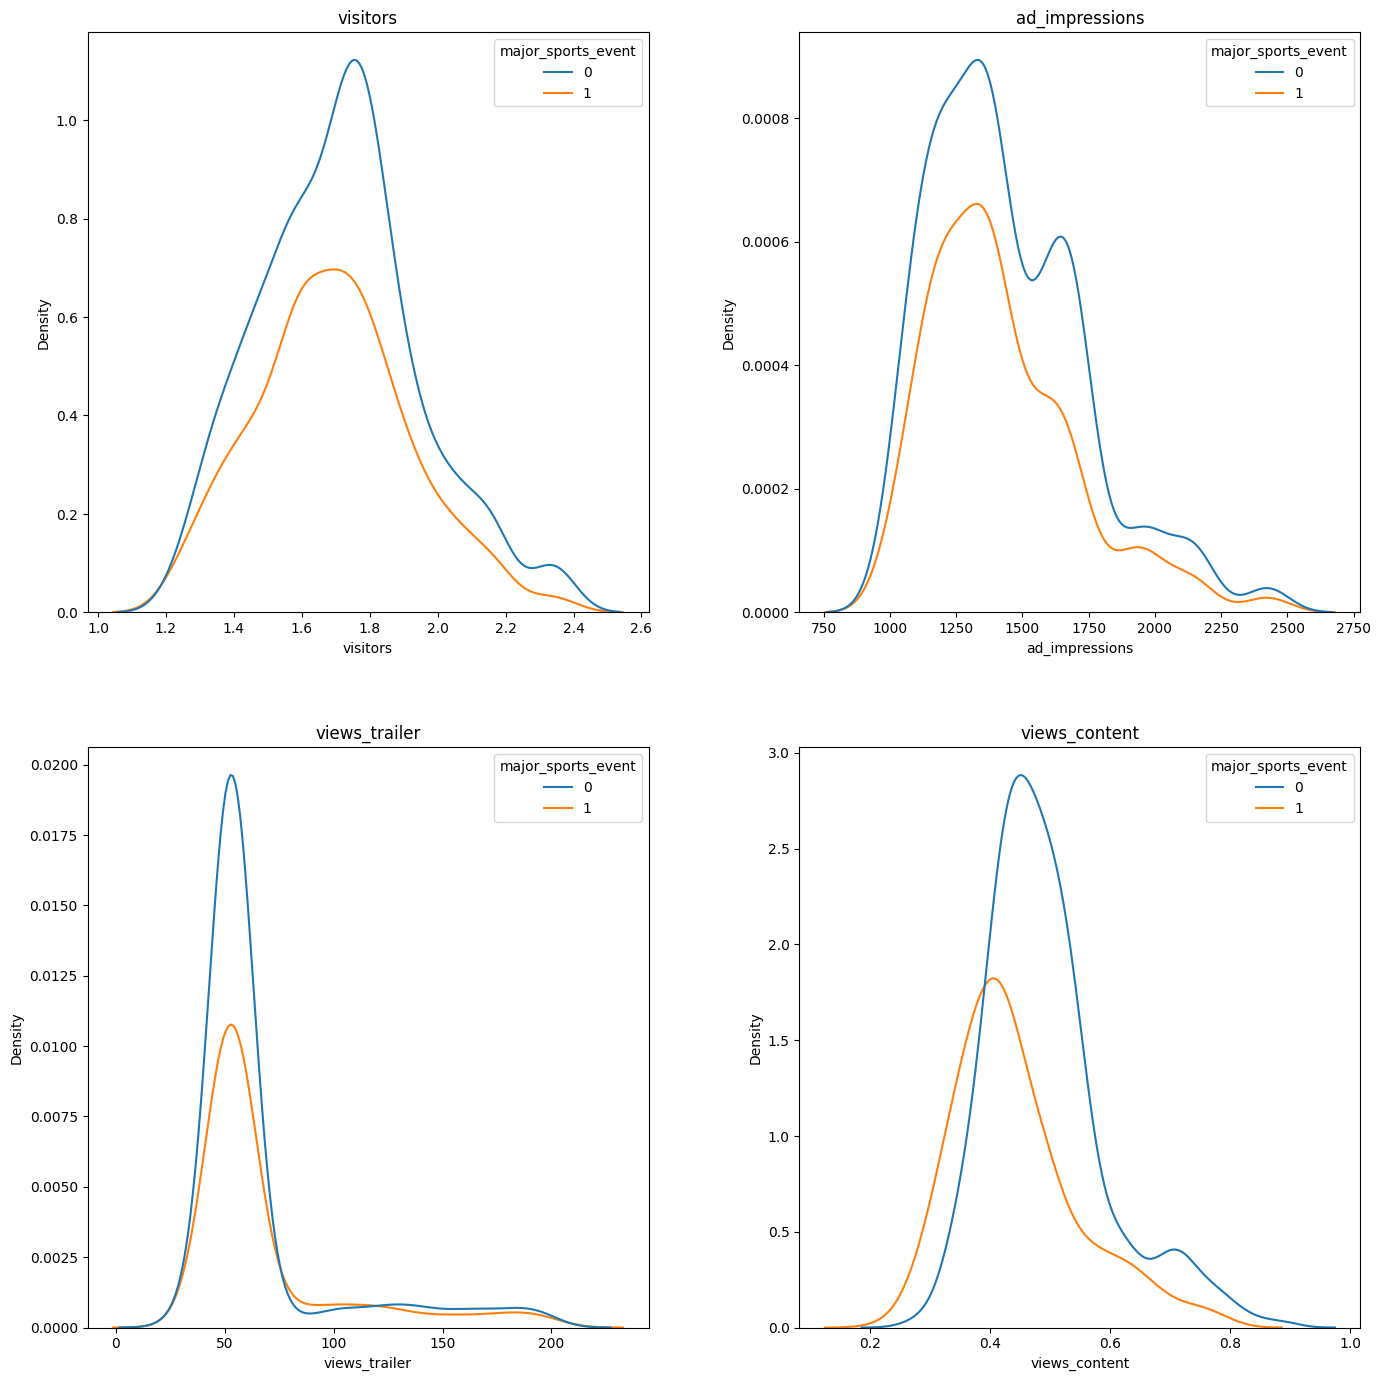

In [ ]:
# Lastly, let's look at numeric variables against discrete variables:

plt.figure(figsize=(15,15))

for i, variable in enumerate(continuous_variables):
  plt.subplot(2, 2, i + 1)
  sns.kdeplot(data = dataset, x = dataset[variable], hue = "major_sports_event", fill = False)
  plt.tight_layout (pad = 5)
  plt.title(variable)

plt.show()

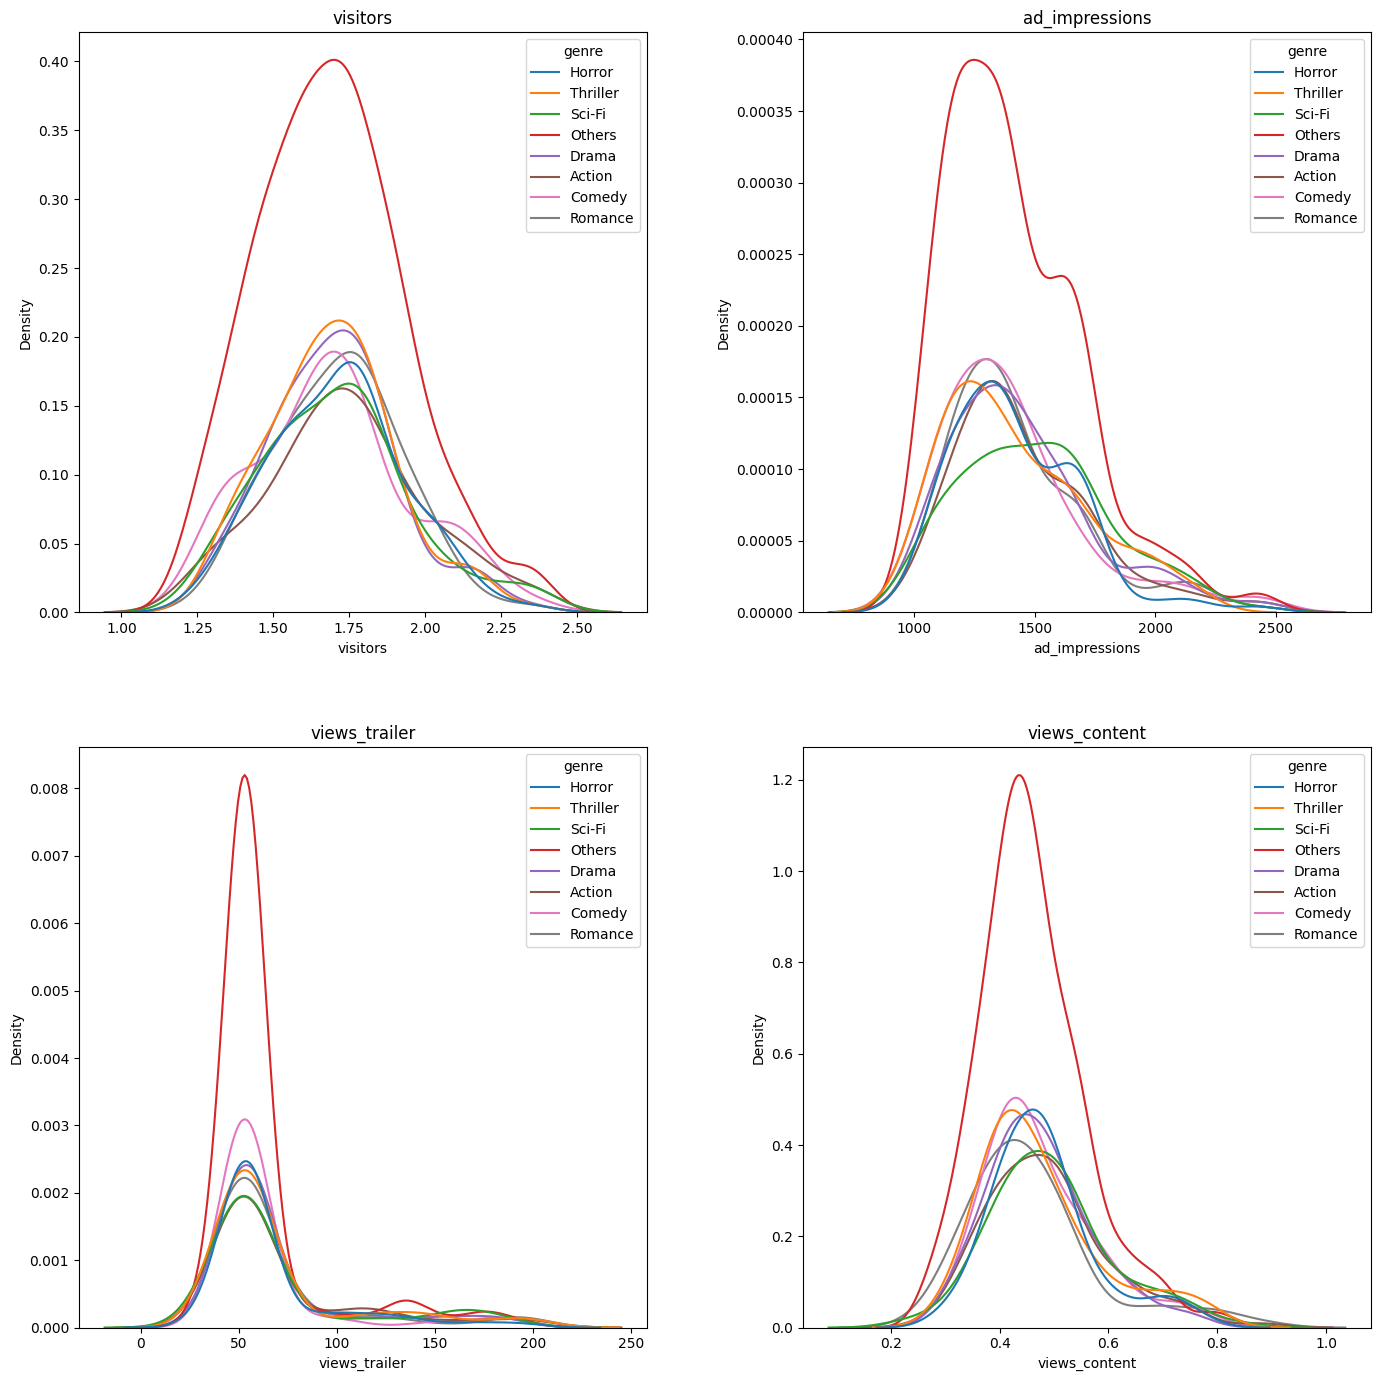

In [ ]:
plt.figure(figsize=(15,15))

for i, variable in enumerate(continuous_variables):
  plt.subplot(2, 2, i + 1)
  sns.kdeplot(data = dataset, x = dataset[variable], hue = "genre", fill = False)
  plt.tight_layout (pad = 5)
  plt.title(variable)

plt.show()

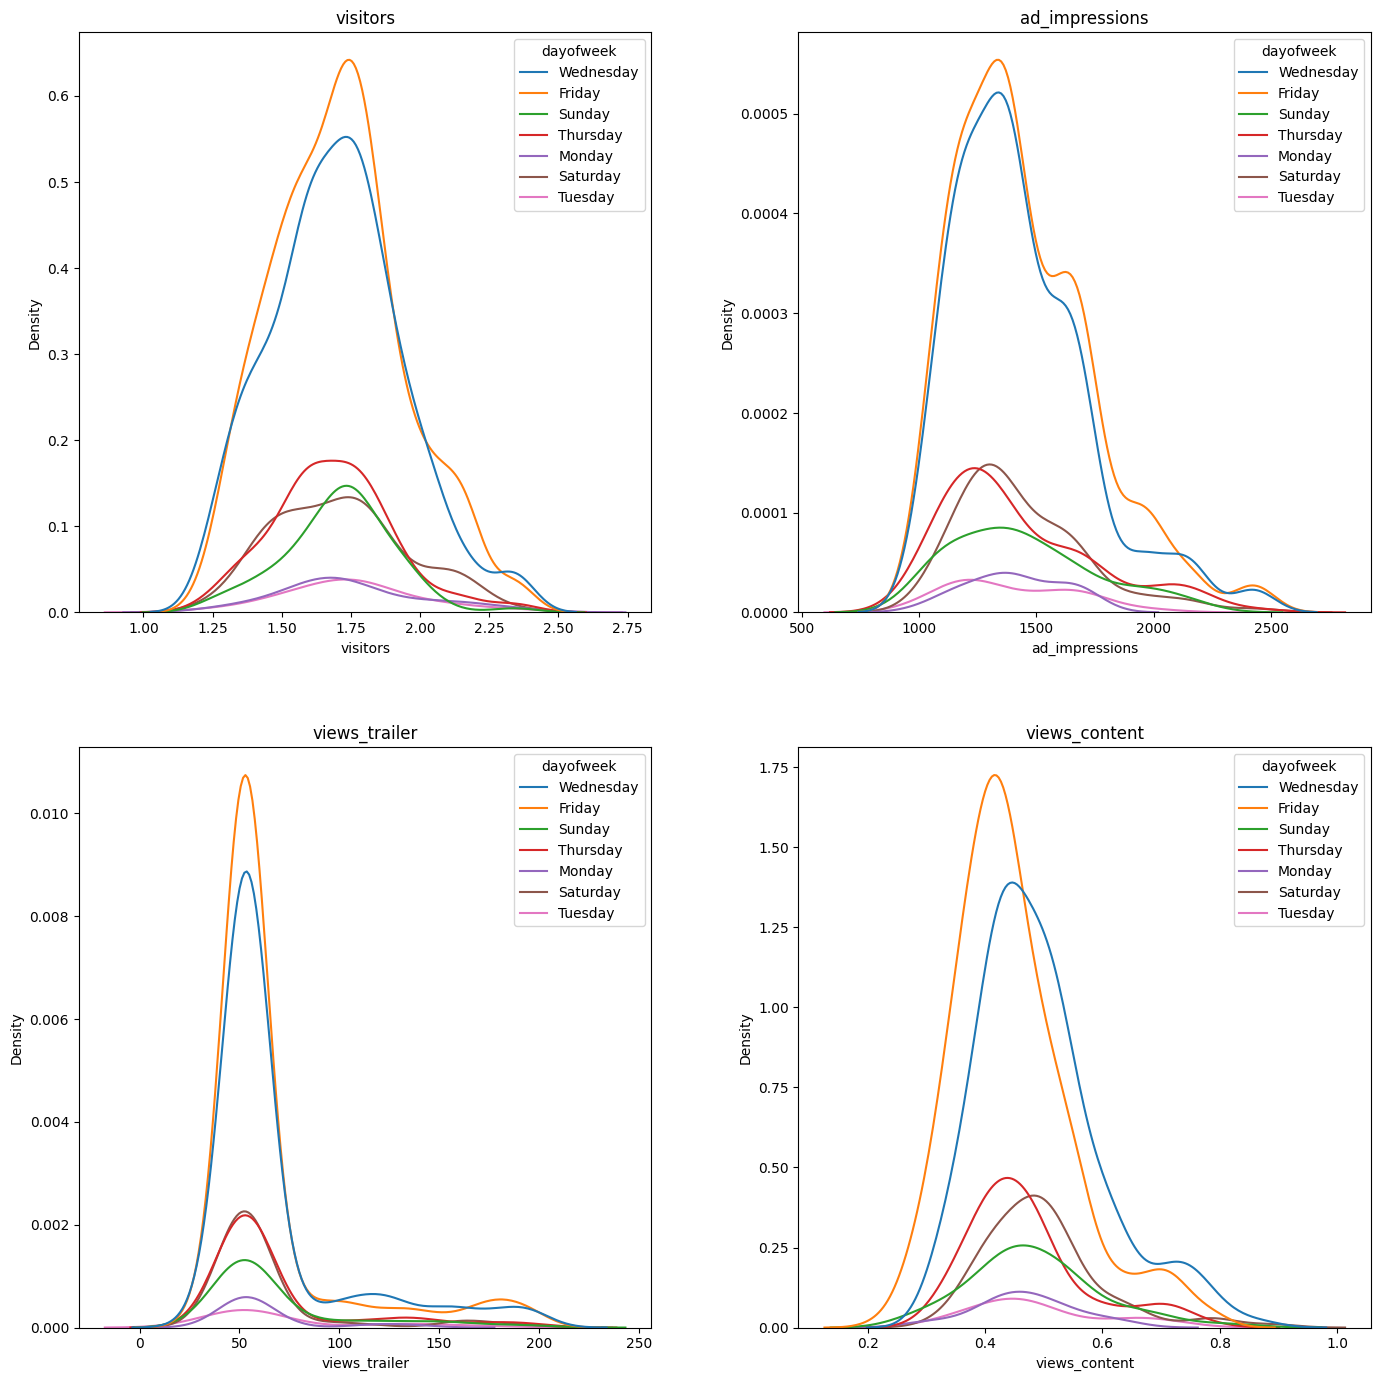

In [ ]:
plt.figure(figsize=(15,15))

for i, variable in enumerate(continuous_variables):
  plt.subplot(2, 2, i + 1)
  sns.kdeplot(data = dataset, x = dataset[variable], hue = "dayofweek", fill = False)
  plt.tight_layout (pad = 5)
  plt.title(variable)

plt.show()

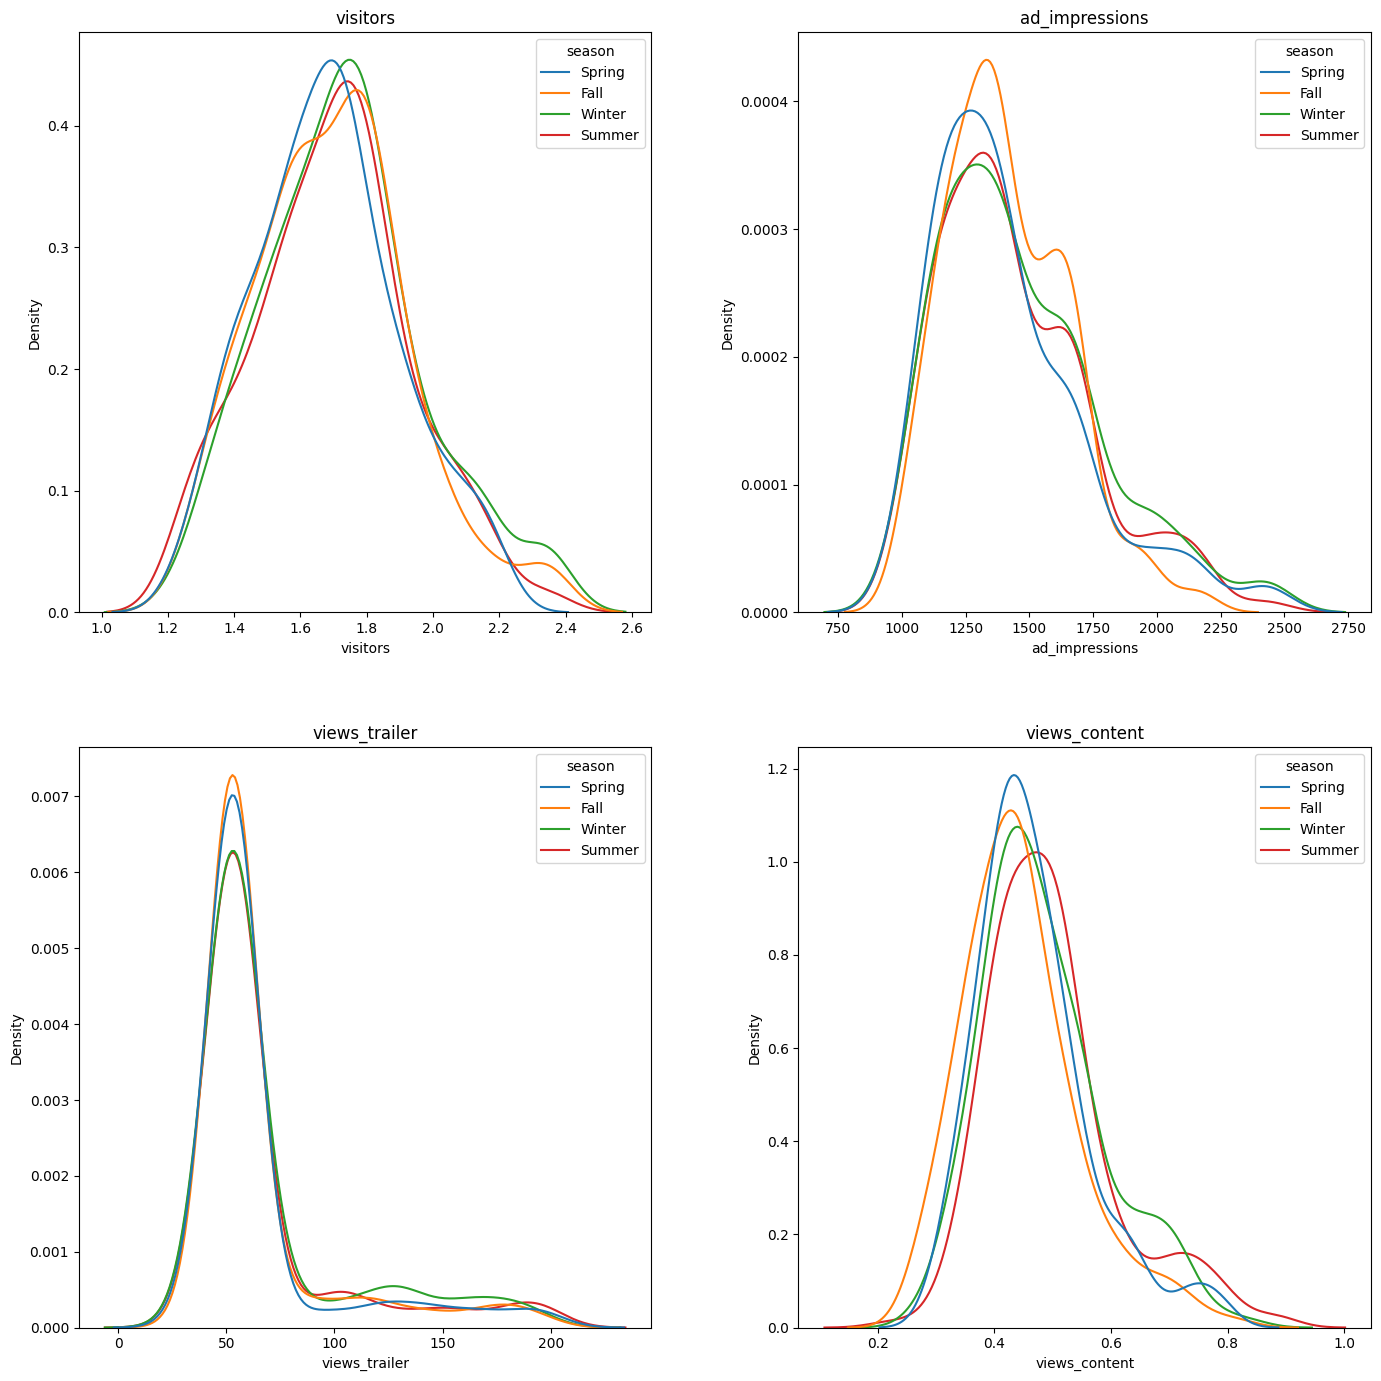

In [ ]:
plt.figure(figsize=(15,15))

for i, variable in enumerate(continuous_variables):
  plt.subplot(2, 2, i + 1)
  sns.kdeplot(data = dataset, x = dataset[variable], hue = "season", fill = False)
  plt.tight_layout (pad = 5)
  plt.title(variable)

plt.show()

- As pointed out earlier when looking at discrete variables against one another, the same patterns that are present in the distributions of the individual discrete variables also show up without anomalies in their respective breakdowns as well. This goes to show there is no significant influence on any of the continuous variables by any of the discrete variables.
- That being said, there is a single plot in all of these that does reflect something a little interesting, and that is the plot of the "views_content" variable broken down by the "major_sports_event" variable. The peak of the distribution for days without a major sports event is slightly offset to the right as compared to that for days with a major sports event. This goes to show the average views for days without a major sports event is slightly higher than that for days with one, on top of the fact that more content pieces are released on days without a major sports event as compared to days with one. This difference is not much though, and is unlikely to cause an issue with our regression later on.

### **Question 1**

What does the distribution of content views look like?

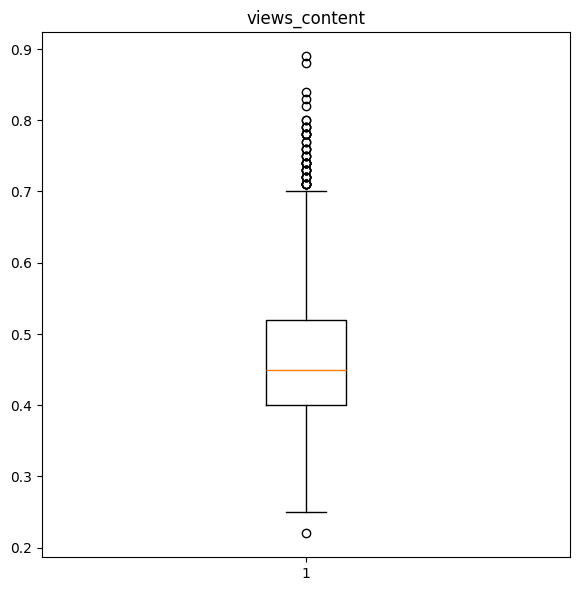

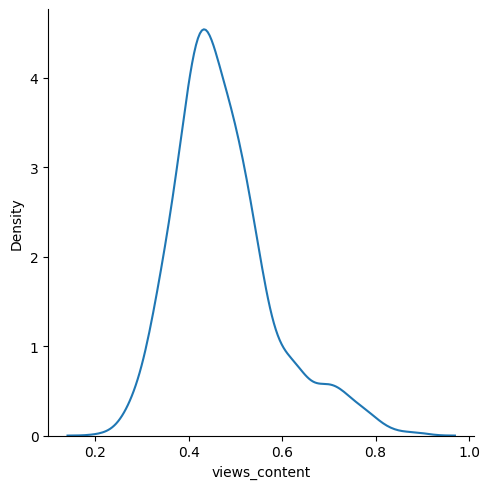

In [ ]:
# To answer this question, we can take a look at a box plot and frequency distribution plot of the "views_content" variable as we had previously done as part of our univariate analysis.

plt.figure(figsize=(15,15))
plt.subplot(2, 2, i + 1)
plt.boxplot (dataset["views_content"], whis = 1.5)
plt.title("views_content")
sns.displot(dataset["views_content"], kind = "kde")

plt.show()

- As we can see from both graphs, we have outliers on the upper end, but the peak of occurence and median are much lower. This goes to show while there are exceptional content pieces that result in very high media consumption on the OTT platform, the majority don't perform as such.
- In the sense that the distribution starts low, peaks towards the middle and then falls off again towards the right, we can say this resembles a normal distribution. In terms of the specific characteristics though, this is from from being normal.

### **Question 2**

What does the distribution of genres look like?

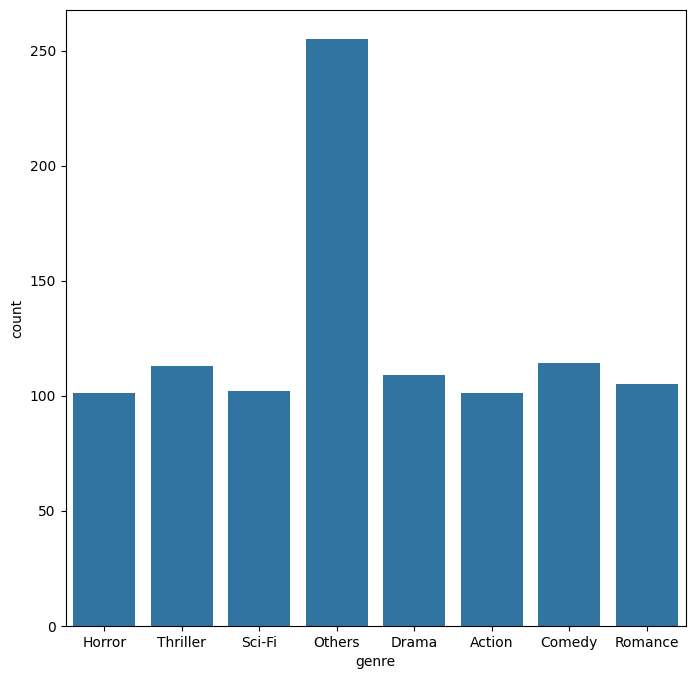

In [ ]:
# Again, we can draw from the frequency distribution of the "genre" variable from our univariate analysis to answer this question.

plt.figure(figsize=(8,8))
sns.countplot(x = dataset["genre"])

plt.show()

- As previously noted in the univariate analysis, all genres seem approximately equally popular, while the ones that are clubbed into the "other" category account for a lot more content than any single genre.

### **Question 3**

The day of the week on which content is released generally plays a key role in the viewership. How does the viewership vary with the day of release?

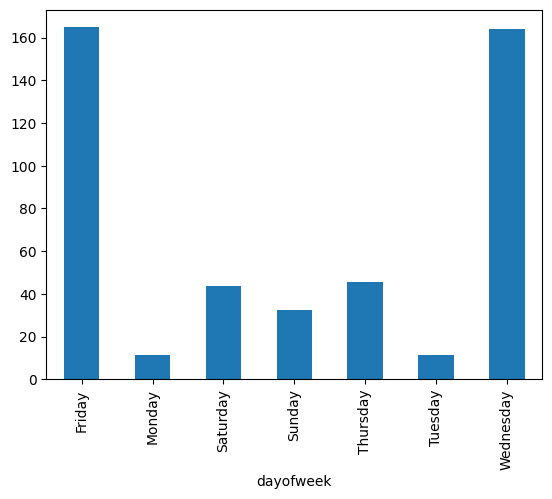

In [ ]:
# Drawing from our bivariate analysis this time, let's look at content views across different days of the week.

views_per_day = dataset.groupby ("dayofweek")["views_content"].sum()

views_per_day.plot (kind="bar")
plt.show()

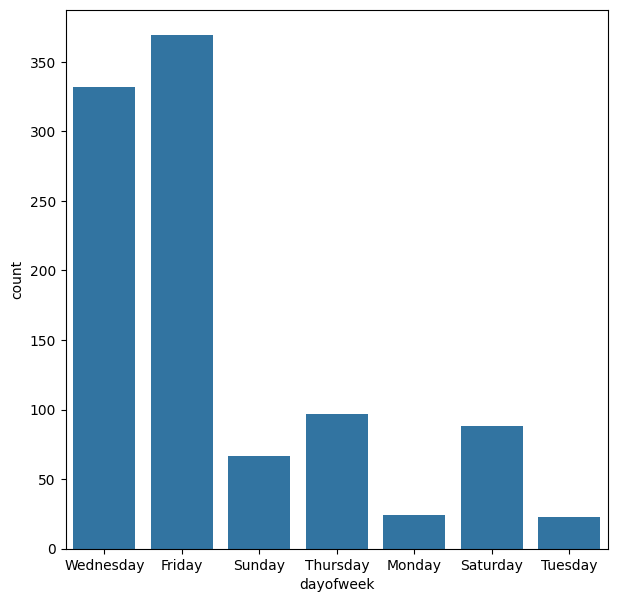

In [ ]:
# Before we make our conclusions, let's quickly look at the frequency distribution of the "dayofweek" variable:

plt.figure(figsize=(7,7))
sns.countplot(x = dataset["dayofweek"])

plt.show()

When we plot total number of views against the day of week, it appears as though content released on Wednesdays and Fridays outperform the content released on all the other days by a large margin.

But when we see the distribution of the days variable itself, we see that a lot of content was released either on Wednesdays or on Fridays to begin with. So it is not surprising that content released on these two days have the most views as well.

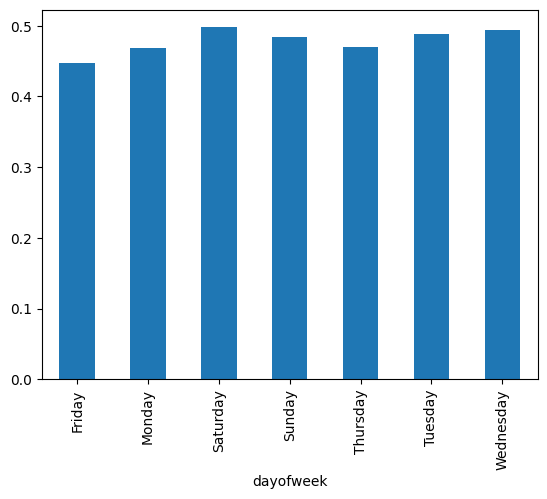

In [ ]:
# If we really want to get a sense for whether content released on any particular day(s) has an advantage over others, we need to look at average views per day.

avg_views_per_day = dataset.groupby ("dayofweek")["views_content"].mean()

avg_views_per_day.plot (kind="bar")
plt.show()

When we see average views per day, we see that there isn't in fact any advantage to a specific day at all. Content released on any day of the week seem to perform approximately equally well.

### **Question 4**

How does the viewership vary with the season of release?

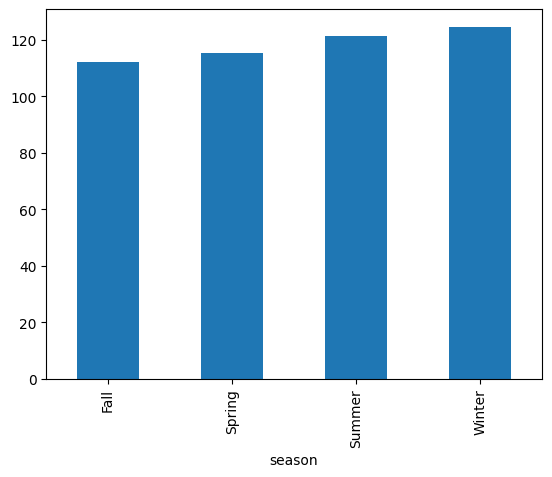

In [ ]:
# Let's look at views across different seasons:

views_per_season = dataset.groupby ("season")["views_content"].sum()

views_per_season.plot (kind="bar")
plt.show()

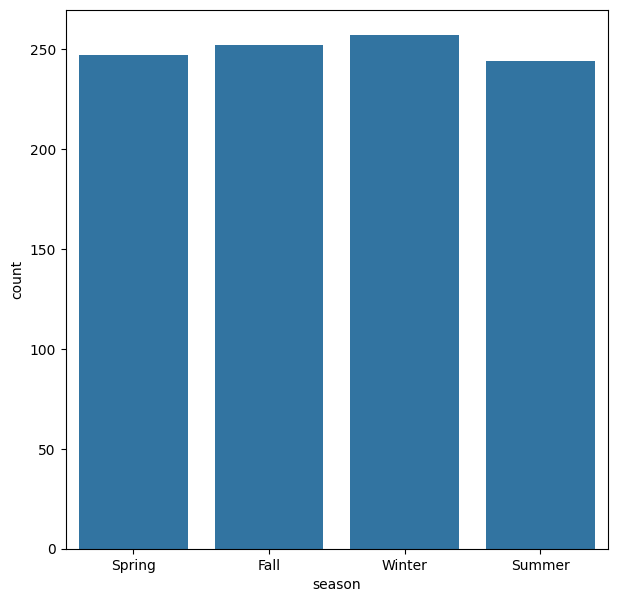

In [ ]:
# Again, before we conclude, let's look at the distribution of the "season" itself.

plt.figure(figsize=(7,7))
sns.countplot(x = dataset["season"])

plt.show()

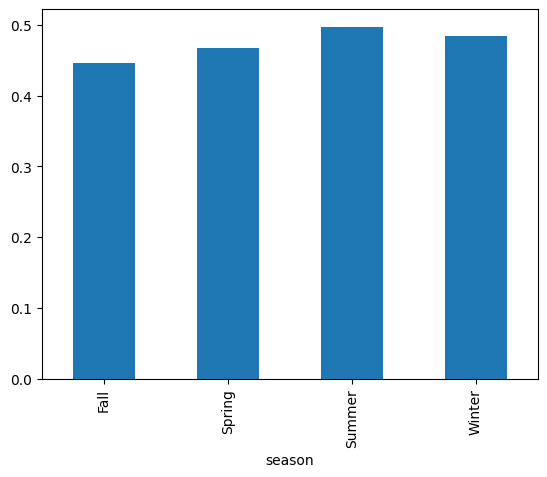

In [ ]:
# Lastly, let's look at the mean views per season:

avg_views_per_season = dataset.groupby ("season")["views_content"].mean()

avg_views_per_season.plot (kind="bar")
plt.show()

- As we can see, content was consistently released across all four seasons. In the light of this, viewership does fluctuate across the seasons, although not by much.
- There is a feeble pattern where views go up in winter, come down in spring, go up again in summer, and slide a little in fall. This might be because of the occurence of holidays within these seasons.

### **Question 5**

What is the correlation between trailer views and content views?

In [ ]:
# We can look at a correlation matrix between all variables and then check for this pair, but since the question only asks for correlation between these two variables, let's address that directly.

correlation = dataset['views_trailer'].corr(dataset['views_content'])

print ("The correlation between trailer views and content views is ", round(float(correlation), 2))

The correlation between trailer views and content views is  0.75


- Our correlation figure of 0.75 suggests a rather strong positive correlation between trailer views and content views, although not perfect.

- This confirms what we had observed by looking at the scatterplot between content views and trailer views from our bivariate analysis earlier as well.

### **Additional Exploration**

We've seen how the content views variable, which is what we're interested in and will be modelling for later, relates to all continuous variables in our dataset as well as a couple of discrete variables within the questions.

There are only two variables left in the dataset for which we havent seen how the content views variable behaves within the questions. Those are the "genre" variable and the "major_sports_event", which are both discrete.

Let's take a look at those now.

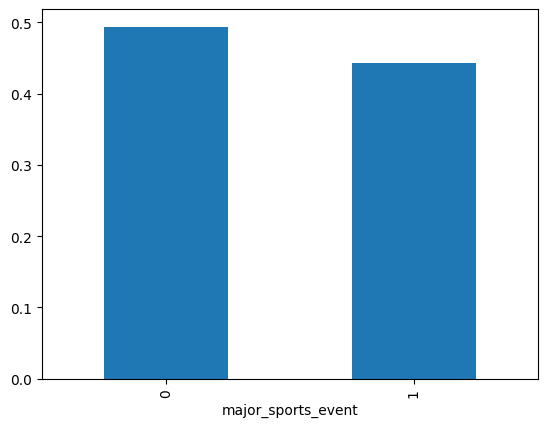

In [ ]:
# Let's start with the "major_sports_event" variable first.

avg_views_per_day_sports = dataset.groupby ("major_sports_event")["views_content"].mean()

avg_views_per_day_sports.plot (kind="bar")
plt.show()

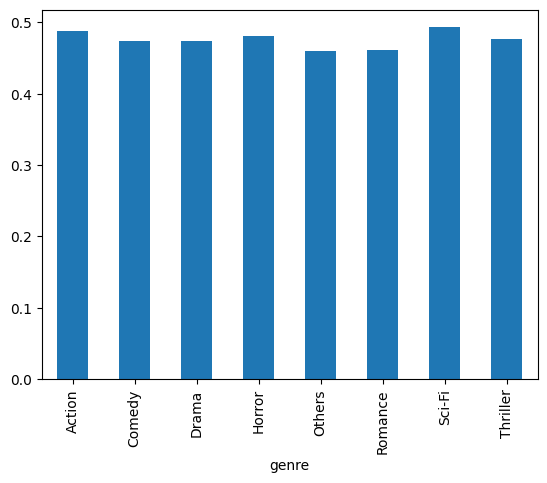

In [ ]:
# Now let's look at how content views behaves against the "genre" variable.

avg_views_per_genre = dataset.groupby ("genre")["views_content"].mean()

avg_views_per_genre.plot (kind="bar")
plt.show()

- When it comes to days on which there were no major sports events, viewership is a little higher as compared to days on which there was a major sports event. The difference isn't very pronounced though, but nonetheless, it might go to show that people might be occupied elsewhere because of which viewership is lower on the platform.
- There seems to be no particular genre that has more views than others, they all seem approximately equally popular.

In [ ]:
# Lastly, let's look at a correlation matrix of the continuous variables to see if it confirms our observations from the visualisations.

dataset[continuous_variables].corr()

,visitors,ad_impressions,views_trailer,views_content
visitors,1.000000,0.030472,-0.028930,0.259136
ad_impressions,0.030472,1.000000,0.009446,0.050022
views_trailer,-0.028930,0.009446,1.000000,0.753962
views_content,0.259136,0.050022,0.753962,1.000000


<Axes: >

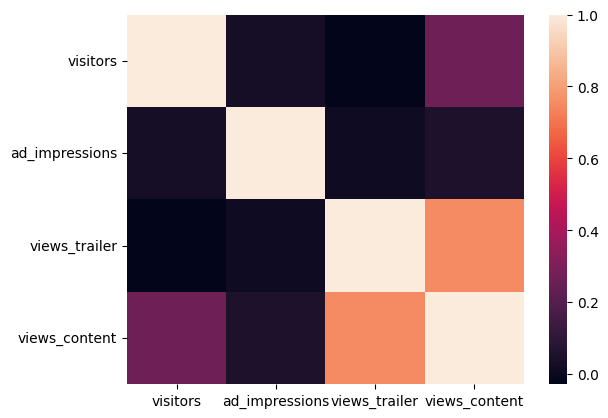

In [ ]:
# Let's visualise the matrix as a heatmap for a better understanding:

sns.heatmap(dataset[continuous_variables].corr())

As we can see, none of the continuous variables have a noteworthy correlation with one another except for the pair of views_trailer and views_content.

### **Insights Summary from the Exploratory Data Analysis**

**Univariate Analysis**

- There are outliers in all of the continuous variables, but they don't seem to be errors or problematic in any other way.
- There are patterns within the distributions of each discrete variable. The days on which there were no major sporting events were a lot more than those where there were, all genres seem approximately equally popular (except the "other" category which accounts for a lot more content than any single genre), a lot of content was released either on Wednesdays or on Fridays by a significant margin as compared to the other days of the week, and
lastly, the release of content across the different seasons of the year seem rather consistent.


**Bivariate Analysis**

- Continuous variables against one another: "views_content", our dependant variable, doesn't seem to have a linear relationship with any other numerical variable except for the "views_trailer" variable.
- Discrete variables against one another: Nothing shows up that is not expected, the patterns that are visible in the individual variables also reflect in their respective breakdowns. Only within the breakdown of the "genre" variable by the "season" variable, some genres seem to be particularly more popular in certain seasons than others.
- Continuous variables against discrete variables: the same patterns that are present in the distributions of the individual discrete variables also show up without anomalies in their respective breakdowns here as well. The plot of the "views_content" variable broken down by the "major_sports_event" variable in particular shows that the average views for days without a major sports event is slightly higher than that for days with one, although the difference is not as much.

## **Model Building - Linear Regression**

In [ ]:
# Let's build our linear regression model, fit the model onto the training dataset, then look at its summary:

modelbld = sm.OLS (y_train, x_train)
modelfit = modelbld.fit()

print (modelfit.summary())

                            OLS Regression Results                            
Dep. Variable:          views_content   R-squared:                       0.792
Model:                            OLS   Adj. R-squared:                  0.785
Method:                 Least Squares   F-statistic:                     129.0
Date:                Sun, 01 Mar 2026   Prob (F-statistic):          1.32e-215
Time:                        05:04:05   Log-Likelihood:                 1124.6
No. Observations:                 700   AIC:                            -2207.
Df Residuals:                     679   BIC:                            -2112.
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.1028    

In [ ]:
# Let's take a look at just the independent variables and their coefficients:

modelfit.params

,0
const,0.102802
visitors,0.129451
ad_impressions,0.000004
major_sports_event,-0.060326
views_trailer,0.002330
genre_Action,-0.006325
genre_Comedy,0.003027
genre_Drama,0.006300
genre_Horror,0.003537
genre_Romance,-0.005774


**Comments on the OLS Summary**

- Let's start by looking at the R squared value of our regression model. We see that it is 0.792. That is relatively high (given that the maximum is 1) and suggests that our model is doing a decent job in explaining the variance in the dataset.

- Next, let's look at the coefficients of our independent variables. We see there are some positive values suggesting a positive correlation between the respective variable and the dependent variable, and some negetive values, suggesting a negetive correlation between the respective variable and the dependent variable. We also see that they are all rather close to 0.

- Let's check to see whether the nature of correlation suggested by the coeffients (positive or negetive) make sense intuitively. For variables where they don't, there might be multicolinearity issues. "visitors", "ad_impressions" and "views_trailer" all have positive coefficients suggesting as these variables increase, they also result in an increase of the dependent variable which is "views_content". This makes sense intuitively. When it comes to our dummy variables across "genre", "dayofweek" and "season", some are positive and some are negetive. This might also be sensible, we will take a closer look when inspecting their Variance Inflaction Factors.

- Lastly, let's look at the p-values column in the summary. Again, we see some are beneath 0.05 while others are not. The ones that are above might not be statistically relevent, meaning, there is a significant likelihood that their corresponding population coefficients are in fact 0. That would imply the respective variable might play no role in predicting the dependant variable and we might benfit from removing it from our regression model. We will look at this later too.

## **Testing the Assumptions of the Linear Regression Model**

### **Testing For MultiColinearity**

- Multicolinearity suggests that two or more independant variables are correlated to one another. If this is the case within the dataset we use to perform our regression, it will pose challenges. The prediction of the regression will not be affected, but it will present issues in the interpretation of the coefficients of the independent variables.

- We will now check to see if multicolinearity is present in our dataset and if so, how we can address it.

In [ ]:
# Let's get a list of the Variance Inflation Factors for every independent variable:

VIF_list = pd.Series ([variance_inflation_factor (x_train, i) for i in range (x_train.shape[1])], index = x_train.columns)

VIF_list

,0
const,103.432742
visitors,1.027837
ad_impressions,1.029390
major_sports_event,1.065689
views_trailer,1.023551
genre_Action,1.340149
genre_Comedy,1.349434
genre_Drama,1.357760
genre_Horror,1.330901
genre_Romance,1.290522


The lowest that the VIF can be is 1. A lot of these variables are actually close to 1 and therefore, they are unlikely to have multicolinearity issues. However, there are some variables for which they are higher.

They are: "dayofweek_Friday", "dayofweek_Wednesday", "dayofweek_Thursday" and "dayofweek_Saturday" in that order. Out of these, the first two have a VIF above 4 and the second two have a VIF above 2. So overall, this isn't too high, but we will look to see if we can address these as well.

We will now start dropping one variable after an another to see if the multicolinearity is removed and how it impacts the effectivity of our regression model.

In [ ]:
# Let's start by dropping the "dayofweek_Friday" variable, then redoing our regression to see how the R squared indicator of effectivity has changed:

x_train_2 = x_train.drop ("dayofweek_Friday", axis = 1)

modelbld_2 = sm.OLS (y_train, x_train_2)
modelfit_2 = modelbld_2.fit()

print ("Initial R Squared: ", round(modelfit.rsquared, 3), "\n", "Current R Squared: ", round(modelfit_2.rsquared, 3), "\n", "Adjusted R Squared: ", round(modelfit_2.rsquared_adj, 3))

# We can see that there is a 0.007 reduction in R square when we drop the "dayofweek_Friday" variable from the dataset. This is negligible and we will therefore confirm the drop of the "dayofweek_Friday" variable.

Initial R Squared:  0.792 
 Current R Squared:  0.785 
 Adjusted R Squared:  0.779


In [ ]:
# Now, we will repeeat the process using our new dataset without the "dayofweek_Friday" variable to find the Variance Inflation Factors:

VIF_list = pd.Series ([variance_inflation_factor (x_train_2, i) for i in range (x_train_2.shape[1])], index = x_train_2.columns)

VIF_list

,0
const,87.614234
visitors,1.026621
ad_impressions,1.028743
major_sports_event,1.058510
views_trailer,1.023471
genre_Action,1.339711
genre_Comedy,1.349019
genre_Drama,1.347076
genre_Horror,1.330901
genre_Romance,1.289042


Something interesting has happened after removing the "dayofweek_Friday" variable: the VIF of all the previously mentioned variables that were high have dropped down to the proximity of 1. This means the high VIF values of these four variables was significantly due to colinearity with the "dayofweek_Friday" variable.

Since all our variables now have a VIF that is within an acceptable range, we can conclude that **multicolinearity has been removed** to a reasonable extent.

### **Removing Statistically Irrelevant Variables**

- Before we proceed to verify the remaining 4 assumptions of linear regression, let's first see if we can remove any variables from our dataset that are negligible in predicting the dependent variable.

- We will do this by looking at the p-values of each variable, and dropping those that for which it is too high one by one to see how the effectivity of the regression is impacted.

In [ ]:
# Let's start by taking a look at our regression summary once again, now with the improved dataset that doesn't contain variables with multicolinearity issues with one another:

print (modelfit_2.summary())

                            OLS Regression Results                            
Dep. Variable:          views_content   R-squared:                       0.785
Model:                            OLS   Adj. R-squared:                  0.779
Method:                 Least Squares   F-statistic:                     130.7
Date:                Sun, 01 Mar 2026   Prob (F-statistic):          4.20e-212
Time:                        05:04:05   Log-Likelihood:                 1113.7
No. Observations:                 700   AIC:                            -2187.
Df Residuals:                     680   BIC:                            -2096.
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.0684    

- We see that our R square has decreased from 0.792 to 0.785 as previously noted, which is not a huge difference after removing one variable because of multicolinearity.

- Now let's take a look at all variables that have a p-value greater than 0.05 and remove them one by one to see how they impact the R square metric of the regression.

In [ ]:
# Let's start by removing the one with the highest p-value, "genre_Comedy". Then, we will look to see how it impacts the R square of the regression:

x_train_3 = x_train_2.drop ("genre_Comedy", axis = 1)


modelbld_3 = sm.OLS (y_train, x_train_3)
modelfit_3 = modelbld_3.fit()

print ("R Squared (after removing multicolinearity): ", round(modelfit_2.rsquared, 3), "\n", "Current R Squared: ", round(modelfit_3.rsquared, 3), "\n", "Adjusted R Squared: ", round(modelfit_3.rsquared_adj, 3))

# We can see the R square is unchanged when we drop the "genre_Comedy" variable from the dataset. This is great and we will therefore confirm the drop of the "genre_Comedy" variable.

R Squared (after removing multicolinearity):  0.785 
 Current R Squared:  0.785 
 Adjusted R Squared:  0.779


In [ ]:
# Now, let's take a look a look at the refreshed p-values of our variables.

x_train_new = x_train_2.drop ("genre_Comedy", axis = 1)

modelbld_3 = sm.OLS (y_train, x_train_new)
modelfit_3 = modelbld_3.fit()

print (modelfit_3.summary())

                            OLS Regression Results                            
Dep. Variable:          views_content   R-squared:                       0.785
Model:                            OLS   Adj. R-squared:                  0.779
Method:                 Least Squares   F-statistic:                     138.1
Date:                Sun, 01 Mar 2026   Prob (F-statistic):          3.76e-213
Time:                        05:04:05   Log-Likelihood:                 1113.6
No. Observations:                 700   AIC:                            -2189.
Df Residuals:                     681   BIC:                            -2103.
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.0692    

In [ ]:
# Next, we will try dropping the "genre_Horror" variable, which has the highest p-value of these, and repeat the process.

x_train_4 = x_train_2.drop ("genre_Horror", axis = 1)


modelbld_4 = sm.OLS (y_train, x_train_4)
modelfit_4 = modelbld_4.fit()

print ("R Squared (after removing multicolinearity): ", round(modelfit_2.rsquared, 3), "\n", "Current R Squared: ", round(modelfit_4.rsquared, 3), "\n", "Adjusted R Squared: ", round(modelfit_4.rsquared_adj, 3))

# We can again see the R square is unchanged when we drop the "genre_Horror" variable from the dataset. This is great and we will therefore confirm the drop of the "genre_Horror" variable.

R Squared (after removing multicolinearity):  0.785 
 Current R Squared:  0.785 
 Adjusted R Squared:  0.779


In [ ]:
# Now, let's take a look a look at the refreshed p-values of our variables.

x_train_new = x_train_new.drop ("genre_Horror", axis = 1)

modelbld_4 = sm.OLS (y_train, x_train_new)
modelfit_4 = modelbld_4.fit()

print (modelfit_4.summary())

                            OLS Regression Results                            
Dep. Variable:          views_content   R-squared:                       0.785
Model:                            OLS   Adj. R-squared:                  0.780
Method:                 Least Squares   F-statistic:                     146.4
Date:                Sun, 01 Mar 2026   Prob (F-statistic):          3.34e-214
Time:                        05:04:05   Log-Likelihood:                 1113.6
No. Observations:                 700   AIC:                            -2191.
Df Residuals:                     682   BIC:                            -2109.
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.0699    

In [ ]:
# Next, we will try dropping the "genre_Thriller" variable, which has the highest p-value of these, and repeat the process.

x_train_5 = x_train_2.drop ("genre_Thriller", axis = 1)


modelbld_5 = sm.OLS (y_train, x_train_5)
modelfit_5 = modelbld_5.fit()

print ("R Squared (after removing multicolinearity): ", round(modelfit_2.rsquared, 3), "\n", "Current R Squared: ", round(modelfit_5.rsquared, 3), "\n", "Adjusted R Squared: ", round(modelfit_5.rsquared_adj, 3))

# We can again see the R square is unchanged when we drop the "genre_Thriller" variable from the dataset. This is great and we will therefore confirm the drop of the "genre_Thriller" variable.

R Squared (after removing multicolinearity):  0.785 
 Current R Squared:  0.785 
 Adjusted R Squared:  0.779


In [ ]:
# Now, let's take a look a look at the refreshed p-values of our variables.

x_train_new = x_train_new.drop ("genre_Thriller", axis = 1)

modelbld_5 = sm.OLS (y_train, x_train_new)
modelfit_5 = modelbld_5.fit()

print (modelfit_5.summary())

                            OLS Regression Results                            
Dep. Variable:          views_content   R-squared:                       0.785
Model:                            OLS   Adj. R-squared:                  0.780
Method:                 Least Squares   F-statistic:                     155.7
Date:                Sun, 01 Mar 2026   Prob (F-statistic):          2.90e-215
Time:                        05:04:05   Log-Likelihood:                 1113.5
No. Observations:                 700   AIC:                            -2193.
Df Residuals:                     683   BIC:                            -2116.
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.0703    

In [ ]:
# Next, we will try dropping the "genre_Drama" variable, which has the highest p-value of these, and repeat the process.

x_train_6 = x_train_2.drop ("genre_Drama", axis = 1)


modelbld_6 = sm.OLS (y_train, x_train_6)
modelfit_6 = modelbld_6.fit()

print ("R Squared (after removing multicolinearity): ", round(modelfit_2.rsquared, 3), "\n", "Current R Squared: ", round(modelfit_6.rsquared, 3), "\n", "Adjusted R Squared: ", round(modelfit_6.rsquared_adj, 3))

# We can again see the R square is unchanged when we drop the "genre_Drama" variable from the dataset. This is great and we will therefore confirm the drop of the "genre_Drama" variable.

R Squared (after removing multicolinearity):  0.785 
 Current R Squared:  0.785 
 Adjusted R Squared:  0.779


In [ ]:
# Now, let's take a look a look at the refreshed p-values of our variables.

x_train_new = x_train_new.drop ("genre_Drama", axis = 1)

modelbld_6 = sm.OLS (y_train, x_train_new)
modelfit_6 = modelbld_6.fit()

print (modelfit_6.summary())

                            OLS Regression Results                            
Dep. Variable:          views_content   R-squared:                       0.785
Model:                            OLS   Adj. R-squared:                  0.780
Method:                 Least Squares   F-statistic:                     166.3
Date:                Sun, 01 Mar 2026   Prob (F-statistic):          2.27e-216
Time:                        05:04:05   Log-Likelihood:                 1113.4
No. Observations:                 700   AIC:                            -2195.
Df Residuals:                     684   BIC:                            -2122.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.0704    

In [ ]:
# Next, we will try dropping the "genre_Sci-Fi" variable, which has the highest p-value of these, and repeat the process.

x_train_7 = x_train_2.drop ("genre_Sci-Fi", axis = 1)


modelbld_7 = sm.OLS (y_train, x_train_7)
modelfit_7 = modelbld_7.fit()

print ("R Squared (after removing multicolinearity): ", round(modelfit_2.rsquared, 3), "\n", "Current R Squared: ", round(modelfit_7.rsquared, 3), "\n", "Adjusted R Squared: ", round(modelfit_7.rsquared_adj, 3))

# We can again see the R square is unchanged when we drop the "genre_Sci-Fi" variable from the dataset. This is great and we will therefore confirm the drop of the "genre_Sci-Fi" variable.

R Squared (after removing multicolinearity):  0.785 
 Current R Squared:  0.785 
 Adjusted R Squared:  0.779


In [ ]:
# Now, let's take a look a look at the refreshed p-values of our variables.

x_train_new = x_train_new.drop ("genre_Sci-Fi", axis = 1)

modelbld_7 = sm.OLS (y_train, x_train_new)
modelfit_7 = modelbld_7.fit()

print (modelfit_7.summary())

                            OLS Regression Results                            
Dep. Variable:          views_content   R-squared:                       0.785
Model:                            OLS   Adj. R-squared:                  0.780
Method:                 Least Squares   F-statistic:                     178.3
Date:                Sun, 01 Mar 2026   Prob (F-statistic):          2.02e-217
Time:                        05:04:05   Log-Likelihood:                 1113.2
No. Observations:                 700   AIC:                            -2196.
Df Residuals:                     685   BIC:                            -2128.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.0703    

In [ ]:
# Next, we will try dropping the "ad_impressions" variable, which has the highest p-value of these, and repeat the process.

x_train_8 = x_train_2.drop ("ad_impressions", axis = 1)


modelbld_8 = sm.OLS (y_train, x_train_8)
modelfit_8 = modelbld_8.fit()

print ("R Squared (after removing multicolinearity): ", round(modelfit_2.rsquared, 3), "\n", "Current R Squared: ", round(modelfit_8.rsquared, 3), "\n", "Adjusted R Squared: ", round(modelfit_8.rsquared_adj, 3))

# We can again see the R square is unchanged when we drop the "ad_impressions" variable from the dataset. This is great and we will therefore confirm the drop of the "ad_impressions" variable.

R Squared (after removing multicolinearity):  0.785 
 Current R Squared:  0.785 
 Adjusted R Squared:  0.779


In [ ]:
# Now, let's take a look a look at the refreshed p-values of our variables.

x_train_new = x_train_new.drop ("ad_impressions", axis = 1)

modelbld_8 = sm.OLS (y_train, x_train_new)
modelfit_8 = modelbld_8.fit()

print (modelfit_8.summary())

                            OLS Regression Results                            
Dep. Variable:          views_content   R-squared:                       0.785
Model:                            OLS   Adj. R-squared:                  0.780
Method:                 Least Squares   F-statistic:                     192.2
Date:                Sun, 01 Mar 2026   Prob (F-statistic):          1.85e-218
Time:                        05:04:05   Log-Likelihood:                 1113.0
No. Observations:                 700   AIC:                            -2198.
Df Residuals:                     686   BIC:                            -2134.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.0770    

In [ ]:
# Next, we will try dropping the "dayofweek_tuesday" variable, which has the highest p-value of these, and repeat the process.

x_train_9 = x_train_2.drop ("dayofweek_Tuesday", axis = 1)


modelbld_9 = sm.OLS (y_train, x_train_9)
modelfit_9 = modelbld_9.fit()

print ("R Squared (after removing multicolinearity): ", round(modelfit_2.rsquared, 3), "\n", "Current R Squared: ", round(modelfit_9.rsquared, 3), "\n", "Adjusted R Squared: ", round(modelfit_9.rsquared_adj, 3))

# We can again see the R square is unchanged when we drop the "dayofweek_tuesday" variable from the dataset. This is great and we will therefore confirm the drop of the "dayofweek_tuesday" variable.

R Squared (after removing multicolinearity):  0.785 
 Current R Squared:  0.785 
 Adjusted R Squared:  0.779


In [ ]:
# Now, let's take a look a look at the refreshed p-values of our variables.

x_train_new = x_train_new.drop ("dayofweek_Tuesday", axis = 1)

modelbld_9 = sm.OLS (y_train, x_train_new)
modelfit_9 = modelbld_9.fit()

print (modelfit_9.summary())

                            OLS Regression Results                            
Dep. Variable:          views_content   R-squared:                       0.784
Model:                            OLS   Adj. R-squared:                  0.780
Method:                 Least Squares   F-statistic:                     207.9
Date:                Sun, 01 Mar 2026   Prob (F-statistic):          2.49e-219
Time:                        05:04:05   Log-Likelihood:                 1112.3
No. Observations:                 700   AIC:                            -2199.
Df Residuals:                     687   BIC:                            -2139.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.0769    

In [ ]:
# Next, we will try dropping the "genre_Action" variable, which has the highest p-value of these, and repeat the process.

x_train_10 = x_train_2.drop ("genre_Action", axis = 1)


modelbld_10 = sm.OLS (y_train, x_train_10)
modelfit_10 = modelbld_10.fit()

print ("R Squared (after removing multicolinearity): ", round(modelfit_2.rsquared, 3), "\n", "Current R Squared: ", round(modelfit_10.rsquared, 3), "\n", "Adjusted R Squared: ", round(modelfit_10.rsquared_adj, 3))

# We can again see the R square is unchanged when we drop the "genre_Action" variable from the dataset. This is great and we will therefore confirm the drop of the "genre_Action" variable.

R Squared (after removing multicolinearity):  0.785 
 Current R Squared:  0.785 
 Adjusted R Squared:  0.779


In [ ]:
# Now, let's take a look a look at the refreshed p-values of our variables.

x_train_new = x_train_new.drop ("genre_Action", axis = 1)

modelbld_10 = sm.OLS (y_train, x_train_new)
modelfit_10 = modelbld_10.fit()

print (modelfit_10.summary())

                            OLS Regression Results                            
Dep. Variable:          views_content   R-squared:                       0.783
Model:                            OLS   Adj. R-squared:                  0.780
Method:                 Least Squares   F-statistic:                     226.3
Date:                Sun, 01 Mar 2026   Prob (F-statistic):          4.40e-220
Time:                        05:04:05   Log-Likelihood:                 1111.2
No. Observations:                 700   AIC:                            -2198.
Df Residuals:                     688   BIC:                            -2144.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.0778    

In [ ]:
# Next, we will try dropping the "genre_Romance" variable, which has the highest p-value of these, and repeat the process.

x_train_11 = x_train_2.drop ("genre_Romance", axis = 1)


modelbld_11 = sm.OLS (y_train, x_train_11)
modelfit_11 = modelbld_11.fit()

print ("R Squared (after removing multicolinearity): ", round(modelfit_2.rsquared, 3), "\n", "Current R Squared: ", round(modelfit_11.rsquared, 3), "\n", "Adjusted R Squared: ", round(modelfit_11.rsquared_adj, 3))

# We can again see the R square is unchanged when we drop the "genre_Romance" variable from the dataset. This is great and we will therefore confirm the drop of the "genre_Romance" variable.

R Squared (after removing multicolinearity):  0.785 
 Current R Squared:  0.785 
 Adjusted R Squared:  0.779


In [ ]:
# Now, let's take a look a look at the refreshed p-values of our variables.

x_train_new = x_train_new.drop ("genre_Romance", axis = 1)

modelbld_11 = sm.OLS (y_train, x_train_new)
modelfit_11 = modelbld_11.fit()

print (modelfit_11.summary())

                            OLS Regression Results                            
Dep. Variable:          views_content   R-squared:                       0.783
Model:                            OLS   Adj. R-squared:                  0.780
Method:                 Least Squares   F-statistic:                     248.4
Date:                Sun, 01 Mar 2026   Prob (F-statistic):          7.47e-221
Time:                        05:04:06   Log-Likelihood:                 1110.2
No. Observations:                 700   AIC:                            -2198.
Df Residuals:                     689   BIC:                            -2148.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.0772    

In [ ]:
# Next, we will try dropping the "dayofweek_Thursday" variable, which has the highest p-value of these, and repeat the process.

x_train_12 = x_train_2.drop ("dayofweek_Thursday", axis = 1)


modelbld_12 = sm.OLS (y_train, x_train_12)
modelfit_12 = modelbld_12.fit()

print ("R Squared (after removing multicolinearity): ", round(modelfit_2.rsquared, 3), "\n", "Current R Squared: ", round(modelfit_12.rsquared, 3), "\n", "Adjusted R Squared: ", round(modelfit_12.rsquared_adj, 3))

# We can see that the R square has dropped by 0.001 when we drop the "dayofweek_Thursday" variable from the dataset. This is great and we will therefore confirm the drop of the "dayofweek_Thursday" variable.

R Squared (after removing multicolinearity):  0.785 
 Current R Squared:  0.784 
 Adjusted R Squared:  0.778


In [ ]:
# Now, let's take a look a look at the refreshed p-values of our variables.

x_train_new = x_train_new.drop ("dayofweek_Thursday", axis = 1)

modelbld_12 = sm.OLS (y_train, x_train_new)
modelfit_12 = modelbld_12.fit()

print (modelfit_12.summary())

                            OLS Regression Results                            
Dep. Variable:          views_content   R-squared:                       0.782
Model:                            OLS   Adj. R-squared:                  0.779
Method:                 Least Squares   F-statistic:                     275.2
Date:                Sun, 01 Mar 2026   Prob (F-statistic):          1.38e-221
Time:                        05:04:06   Log-Likelihood:                 1109.0
No. Observations:                 700   AIC:                            -2198.
Df Residuals:                     690   BIC:                            -2153.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.0792    

In [ ]:
# Great, we now have no variable that has a p-value greater than 0.05.

# Let's check to see how many variables we have dropped:

print ("No.of variables before dropping statistically irrelevant variables: ", x_train_2.shape[1], "\n", "No.of variables after dropping statistically irrelevant variables: ", x_train_new.shape[1])

# We see that we have dropped 10 variables.

No.of variables before dropping statistically irrelevant variables:  20 
 No.of variables after dropping statistically irrelevant variables:  10


In [ ]:
# Now, let's check to see what our R square was when we began and what it is now after removing our variables:

print ("R square before dropping statistically irrelevant variables: ", round(modelfit_2.rsquared,3), "\n", "R square after dropping statistically irrelevant variables: ", round(modelfit_12.rsquared,3))

# We can see the R square has decreased by 0.003 after dropping statistically irrelevant variables. Given that we removed 10 variables from our dataset, this drop is negligible.

R square before dropping statistically irrelevant variables:  0.785 
 R square after dropping statistically irrelevant variables:  0.782


- R square has decreased by 0.003 after dropping 10 statistically irrelevant variables from the dataset, and is therefore negligible. This confirms the validity of our direction in removing these variables as they play a marginal role in predicting the dependant variable.

### **Testing for Linearity and Independence**

- The assumption of linearity suggests that the line of best fit is linearly related to the variables that it is summarising.

- The assumption of independance suggests that the residuals are independent of one another, or in other words, we must not be able to predict one residual given another.

In [ ]:
# Let's first create a dataset that contains our actual y-values (y is "views_content"), predicted y-values, and residuals:

asstest_dataset = pd.DataFrame()

asstest_dataset["y_actual"] = y_train.values.flatten()
asstest_dataset["y_predicted"] = modelfit_12.fittedvalues.values
asstest_dataset["residuals"] = modelfit_12.resid.values

asstest_dataset.head()

,y_actual,y_predicted,residuals
0,0.40,0.451651,-0.051651
1,0.70,0.677406,0.022594
2,0.42,0.440091,-0.020091
3,0.55,0.561160,-0.011160
4,0.59,0.548733,0.041267


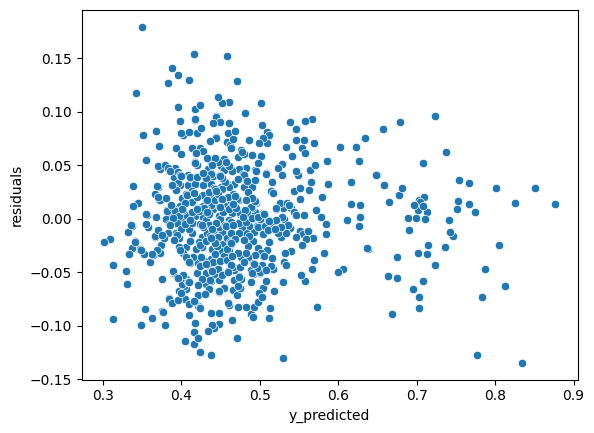

In [ ]:
# Great, now let's plot our residuals against our predicted y values:

sns.scatterplot(data= asstest_dataset, x= "y_predicted", y= "residuals")

plt.show()

- We see that there is no clear pattern when we plot the residuals against the predicted values of the model, therefore, that means there is not much of a non-linearity present between our model and the variables that it is summarising.

- There is a concentration of points towards the left side, but that just goes to show how the datapoints are distributed, and not so much the nature of their relationship with the line of best fit.

- Overall, the graph reflects a cloud of scattered points, which is good and confirms that our line of best fit from the regression does have a linear relationship with the variables that it is summarising. **Therefore, we can confirm that our assumption of linearity has been met.**

- We can also conclude that the residuals are independent of one another, since we will not be able to estimate one residual given another. Therefore, **we can confirm our assumption of independence is also satisfied.**

### **Testing for Normality**

- The assumption of normality suggests that the residuals are normally distributed.

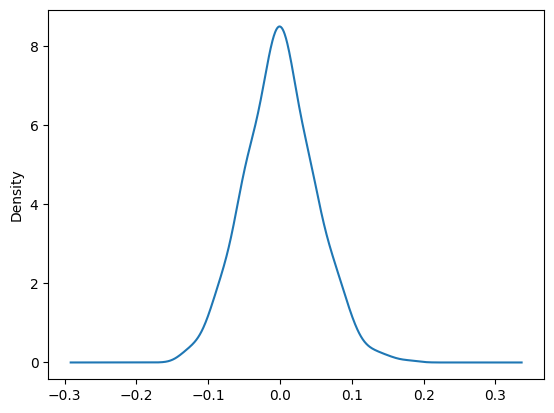

In [ ]:
# Let's visualise the distribution of the residuals to see if it is normal:

asstest_dataset["residuals"].plot (kind = "density")

plt.show()

- Based on looking at the frequency distribution of the residuals, we can say it is reasonably normal.

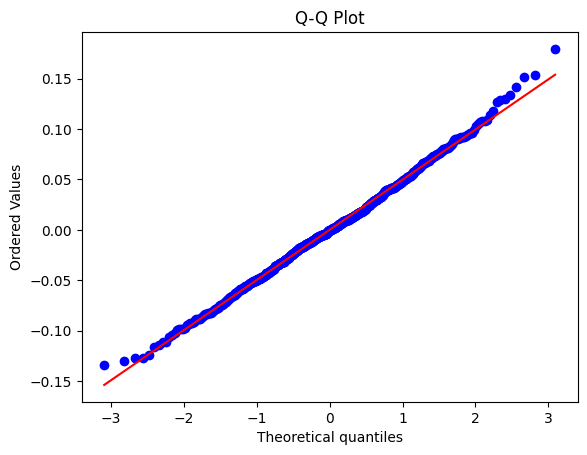

In [ ]:
# Another way we can judge normality of the distribution is through a Q-Q plot (quantile to quantile plot) that will compare the quantiles of our residual distribution to the corresponding ones of a perfect normal distribution.

stats.probplot (asstest_dataset['residuals'], dist = "norm", plot = pylab)
plt.title("Q-Q Plot")
plt.show()

- Based on looking at the graph, we can see the points almost perfectly align with out 45 degree diagonal. The extremes deviate slightly from it, but that is negligible.

- This confirms what we previously observed from looking at the frequency distribution of our residuals that the distribution is normal.

In [ ]:
# We can also check for normality using the Shapiro_Wilk's test (a hypothesis test) which is more statistically precise:

stats.shapiro(asstest_dataset['residuals'])

ShapiroResult(statistic=np.float64(0.9973648367157086), pvalue=np.float64(0.3270039869571204))

- Since our p-value from the Shapiro Wilk's test is 0.32 which is greater than 0.05, we can say we lack sufficient evidence that the null hypothesis is not true.

- In other words, the Shapiro Wilk's test also confirms our observations from the previous visualisations that the distribution of residuals is in fact normal. **We can therefore conclude that our assumption of normality has been met.**

### **Testing for Homoscedasticity**

- The assumption of homoscedasticity suggests that the variance of residuals is constant as a function of the predicted values of the dependant variable.

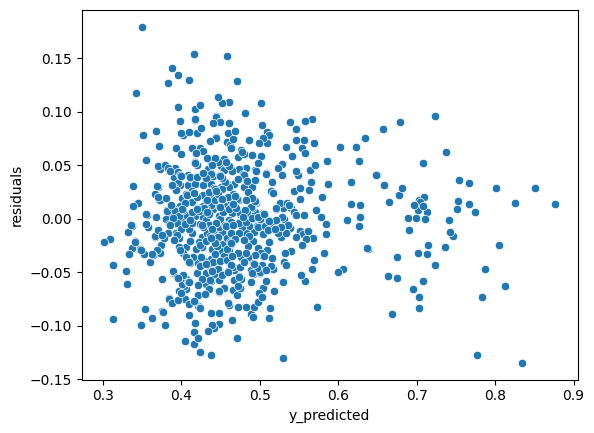

In [ ]:
# Let's check for Homoscedasticity by first looking at the distribution of residuals against predicted y values:

sns.scatterplot(data= asstest_dataset, x= "y_predicted", y= "residuals")

plt.show()

- We can see the variance is rather symmetric around 0.00 on the y-axis and remains that way as the predicted y values increase. This would suggest the residuals are homoscedastic.

In [ ]:
# Another, more statistically precise way to check for homoscedasticity is with the Goldfeld-Quandt test:

sms.het_goldfeldquandt (asstest_dataset['residuals'], x_train_new)

(np.float64(1.1394767833865962), np.float64(0.11458935282308841), 'increasing')

- Since our p-value from the Goldfeld-Quandt test is 0.11 which is greater than 0.05, we can say we lack sufficient evidence that the null hypothesis is not true.

- In other words, the Goldfeld-Quandt test confirms our previous observation from the visualisation of residuals against predicted y values that the residuals are homoscedastic. **We can therefore conclude that our assumption of homoscedasticity has been met.**

## **Model Performance Evaluation**

In [ ]:
# Let's see what columns are contained within our x_train and x_test datasets respectively, and make necessary changes onto the x_test dataset:

print (x_train_new.columns, "\n\n", x_test.columns)


Index(['const', 'visitors', 'major_sports_event', 'views_trailer',
       'dayofweek_Monday', 'dayofweek_Saturday', 'dayofweek_Wednesday',
       'season_Spring', 'season_Summer', 'season_Winter'],
      dtype='object') 

 Index(['const', 'visitors', 'ad_impressions', 'major_sports_event',
       'views_trailer', 'genre_Action', 'genre_Comedy', 'genre_Drama',
       'genre_Horror', 'genre_Romance', 'genre_Sci-Fi', 'genre_Thriller',
       'dayofweek_Friday', 'dayofweek_Monday', 'dayofweek_Saturday',
       'dayofweek_Thursday', 'dayofweek_Tuesday', 'dayofweek_Wednesday',
       'season_Spring', 'season_Summer', 'season_Winter'],
      dtype='object')


In [ ]:
# Now let's drop all the columns in the x_test dataset that we had previously removed from the x_train dataset:

x_test_new = x_test.drop (["ad_impressions", "genre_Action", "genre_Romance", "genre_Comedy", "genre_Drama", "genre_Horror", "genre_Sci-Fi", "genre_Thriller", "dayofweek_Friday", "dayofweek_Thursday", "dayofweek_Tuesday"], axis = 1)

# Now let's check to see if they both have the same columns:

print (x_train_new.columns, "\n\n", x_test_new.columns)

Index(['const', 'visitors', 'major_sports_event', 'views_trailer',
       'dayofweek_Monday', 'dayofweek_Saturday', 'dayofweek_Wednesday',
       'season_Spring', 'season_Summer', 'season_Winter'],
      dtype='object') 

 Index(['const', 'visitors', 'major_sports_event', 'views_trailer',
       'dayofweek_Monday', 'dayofweek_Saturday', 'dayofweek_Wednesday',
       'season_Spring', 'season_Summer', 'season_Winter'],
      dtype='object')


- Great, now both the x_train and x_test datasets have the same columns.

In [ ]:
# Let's predict what our y values will be on the test set using our regression equation:

y_pred = modelfit_12.predict (x_test_new)

# Now let's find the Root Mean Squared Errors against our line of best fit for both the training and testing datasets:

rmse_train = np.sqrt(mean_squared_error(asstest_dataset['y_actual'], asstest_dataset['y_predicted']))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))

print ("RMSE from training dataset: ", round(rmse_train, 3), "\n", "RMSE from testing dataset: ", round(rmse_test, 3))

RMSE from training dataset:  0.05 
 RMSE from testing dataset:  0.052


- We see that the Root Mean Squared Error (also called Standard Error) has gone up in the testing dataset by 0.002, which is negligible.

- We can therefore say our line of best fit satisfactorility explains the variance not just in our training dataset but also in the testing dataset.

- Since the two RMSEs are comparable, we can also say our regression model is not an overfit.

In [ ]:
# Let's also find the Mean Absolute Errors against our line of best fit for both the training and testing datasets:

mae_train = mean_absolute_error(asstest_dataset['y_actual'], asstest_dataset['y_predicted'])
mae_test = mean_absolute_error(y_test, y_pred)

print ("MAE from training dataset: ", round(mae_train, 3), "\n", "MAE from testing dataset: ", round(mae_test, 3))

MAE from training dataset:  0.039 
 MAE from testing dataset:  0.042


- Over here, the Mean Absolute Error has gone up in the testing dataset by 0.003, which is also negligible.

- Both RMSE and MAE qualitatively speak to the same attribute of the extent to which datapoints deviate from the line of best fit. Given that they are both comparable between the training and testing datasets, we can safely say that our regression model is not overfit.

In [ ]:
# Lastly, let's check the R square of our regression in the testing dataset and how it compares to that in our training dataset:

r2_train = r2_score (asstest_dataset['y_actual'], asstest_dataset['y_predicted'])
r2_test = r2_score(y_test, y_pred)

print ("R square from training dataset: ", round(r2_train, 3), "\n", "R square from testing dataset: ", round(r2_test, 3))


R square from training dataset:  0.782 
 R square from testing dataset:  0.75


- We see that R square has gone down by 0.03 in the testing dataset, but that is still acceptable as it is a low figure.

- Based on our observations after testing the parameters of RMSE, MAE and R Square for the line of best fit against the training and testing datasets, **we can conclude that our regression model is doing a satisfactory job in predicting the dependent variable of "views_content".**

## **Actionable Insights and Recommendations**

In [ ]:
# Let's look at the summary of our final regression once again:

print (modelfit_12.summary())

                            OLS Regression Results                            
Dep. Variable:          views_content   R-squared:                       0.782
Model:                            OLS   Adj. R-squared:                  0.779
Method:                 Least Squares   F-statistic:                     275.2
Date:                Sun, 01 Mar 2026   Prob (F-statistic):          1.38e-221
Time:                        07:13:27   Log-Likelihood:                 1109.0
No. Observations:                 700   AIC:                            -2198.
Df Residuals:                     690   BIC:                            -2153.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.0792    

In [ ]:
# Let's look at just the parameters, which is what the equation of our final line of best fit will be:

modelfit_12.params

,0
const,0.079174
visitors,0.129986
major_sports_event,-0.059599
views_trailer,0.002337
dayofweek_Monday,0.024991
dayofweek_Saturday,0.049729
dayofweek_Wednesday,0.039185
season_Spring,0.024110
season_Summer,0.043361
season_Winter,0.028774


**Interpretations of the parameters of our equation**

- We have a constant which is positive and small. This implies even when the values of all other variables in the equation is 0, we will still have some viewership for the content. This might be attributed to any internal testing and viewership from the platform.

- "major_sports_event" is the only variable that negetively impacts the content viewership, meaning, when there is a major sports event, the viewership is lesser. This makes sense intuitively and also confirms what we previously saw in the relationship between "views_content" and "major_sports_event" in the Bivariate Analysis stage of our Exploratory Data Analysis.

- The variable of "visitors" has the highest coefficiant of all and also by a significant relative margin. This implies that the number of visitors to the platform has the highest impact on content viewership as compared to any other factor.

- The variable of "genre" that was present in our original dataset in completely gone in our equation of regression. This implies that the genre of the content has no bearing on the viewership of content.

- The day of week on which the content is released does have an impact, with ones that are released on the days of Monday, Saturday or Wednesday receiving a higher viewership.

- The season in which the content is released also has an impact, with ones released in summer receiving the most viewership followed by spring and winter and lastly, fall.

- The "views_trailer" variable has the smallest coefficient of all variables and also by a significant relative margin, suggesting that its impact on content viewership is minimal.

- Overall, the coefficiants are rather small (magnitude smaller than 0.1) except for the "visitors" variable which has a coefficiant greater than 0.1. This might point to the fact that each variable plays only a minor role in influencing the content viewership on its own, but it is when they combine that we really see an impact. It might also be in part because the content viewership variable is measured in millions.

**Key Takeaways for the Business**

- Allocate resources to increase visitors to the platform, which is the greatest factor by a significant relative margin that impacts content viewership.

- Apart from increasing the visitors to the platform, focus on releasing content on Saturdays, Wednesdays and Mondays.

- Try to release more content in Summer, then secondarily in Spring and Winter.

- Avoid releasing content on days where there is some kind of a major sports event taking place.